# IOB projekt - Przewidywanie chęci założenia lokaty terminowej

Temat szczególny prezentacji
-----------
Ocena jakości modelu i jej implementacja w bibliotece scikit-learn.

# Przegląd danych


Wczytywanie danych

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns

tutaj jest tekst

In [81]:
df = pd.read_csv("lokata/lokata.csv", delimiter=';')

Oglądanie danych

In [82]:
df.head(n=10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [84]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Histogramy zmiennych

In [85]:
import matplotlib.pyplot as plt

In [86]:
print(len(df.columns))

21


In [87]:
df["y"] = df["y"].replace({"yes":1, "no":0})

/tmp/ipykernel_1295/479518289.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["y"] = df["y"].replace({"yes":1, "no":0})


# Wizualizacja danych

/tmp/ipykernel_95792/2096156463.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12,10))


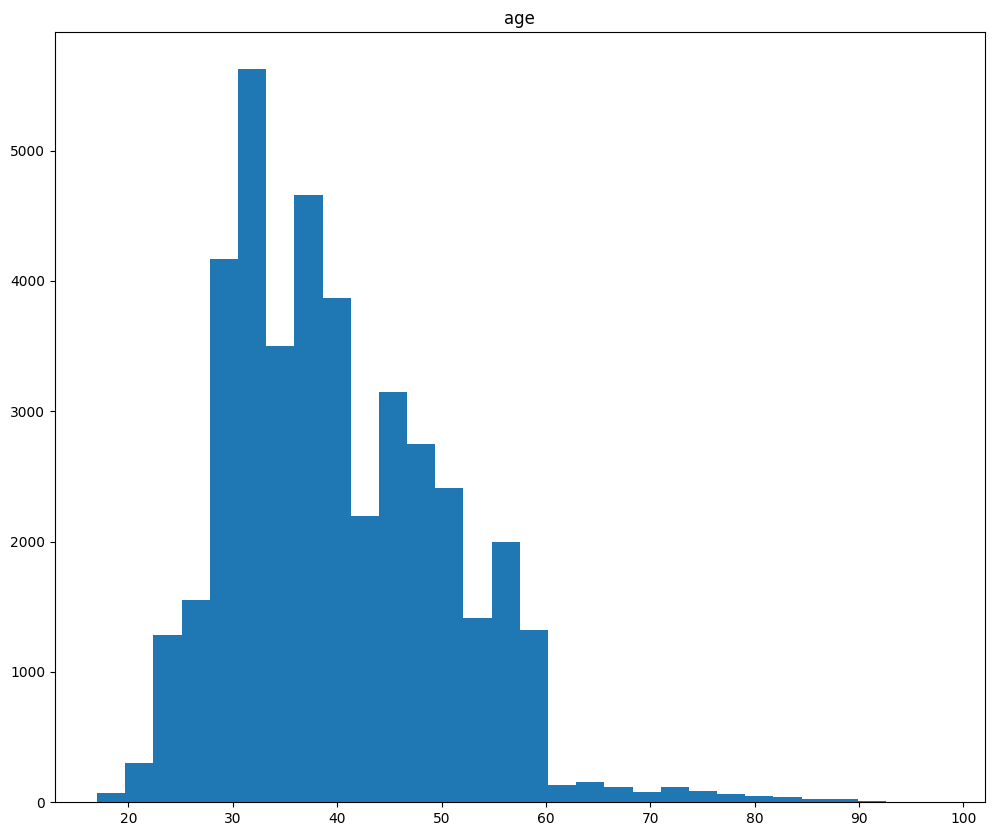

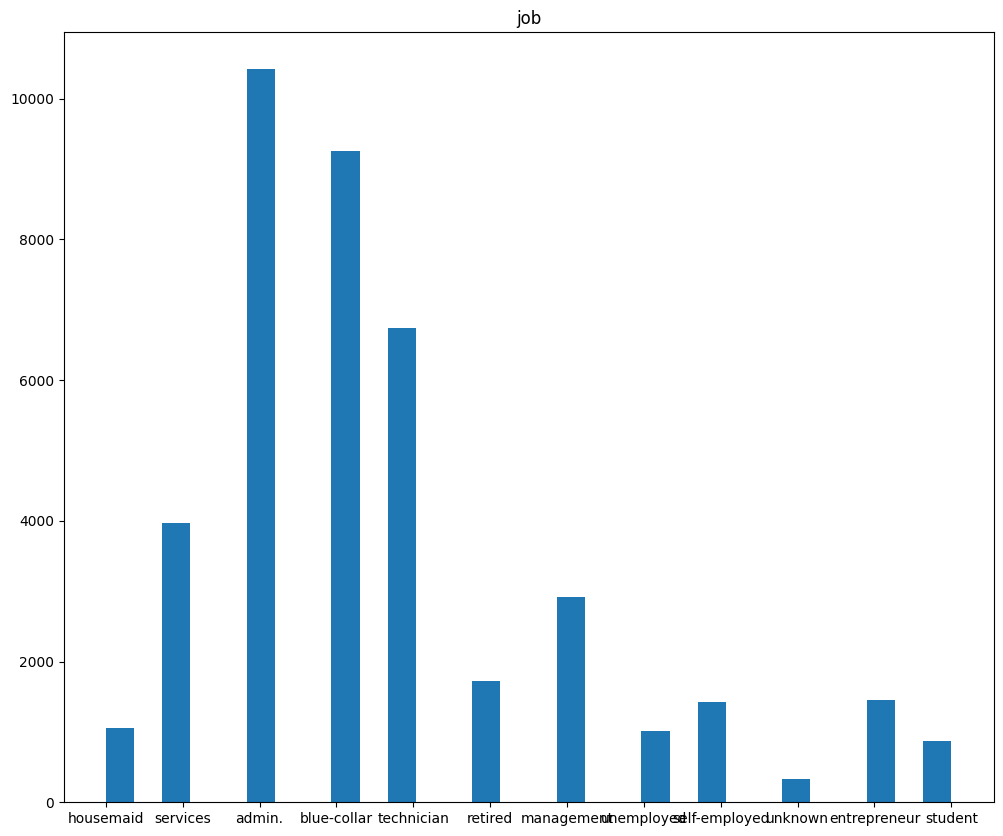

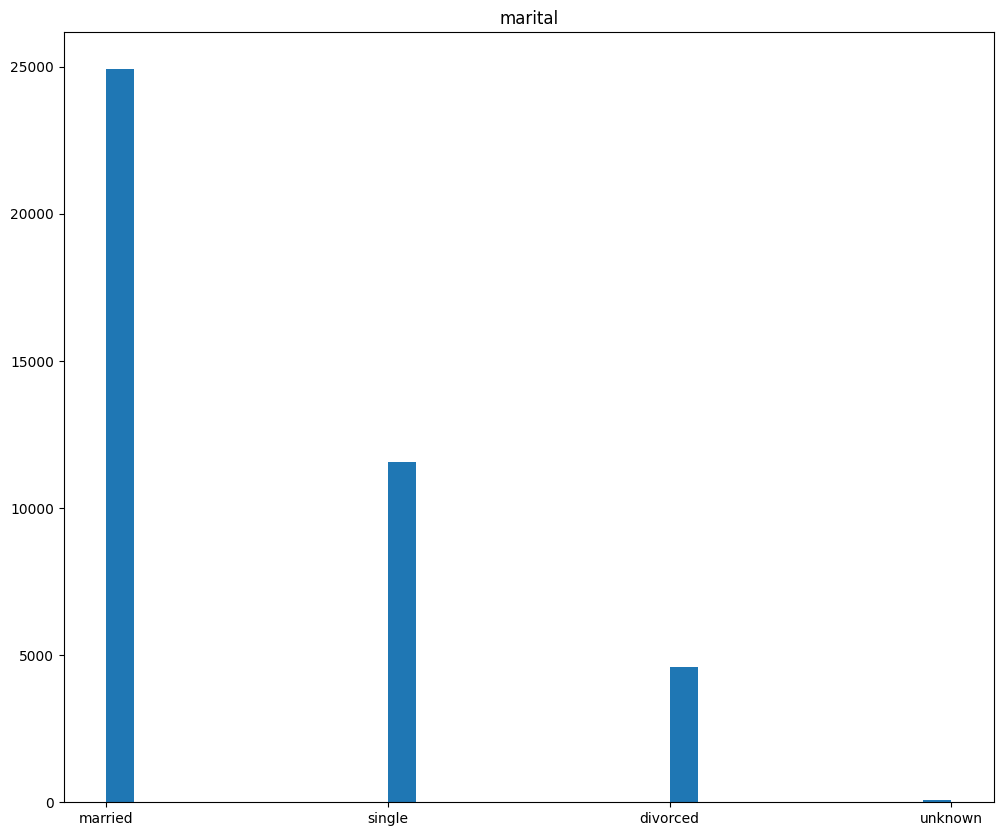

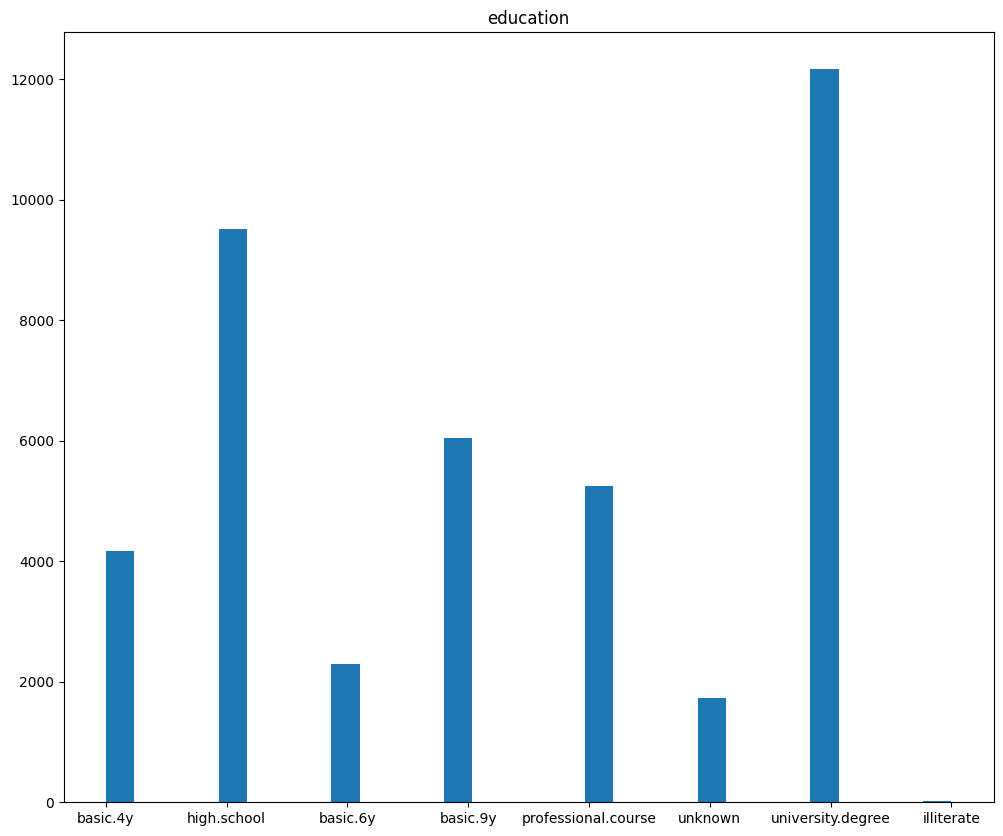

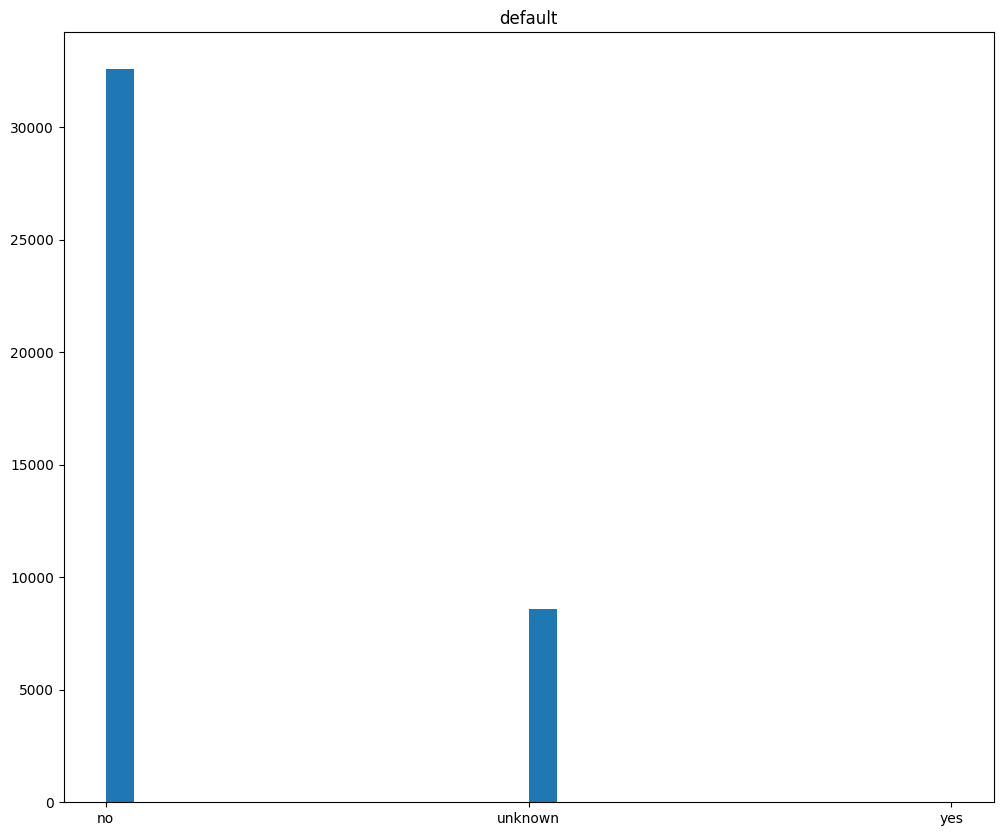

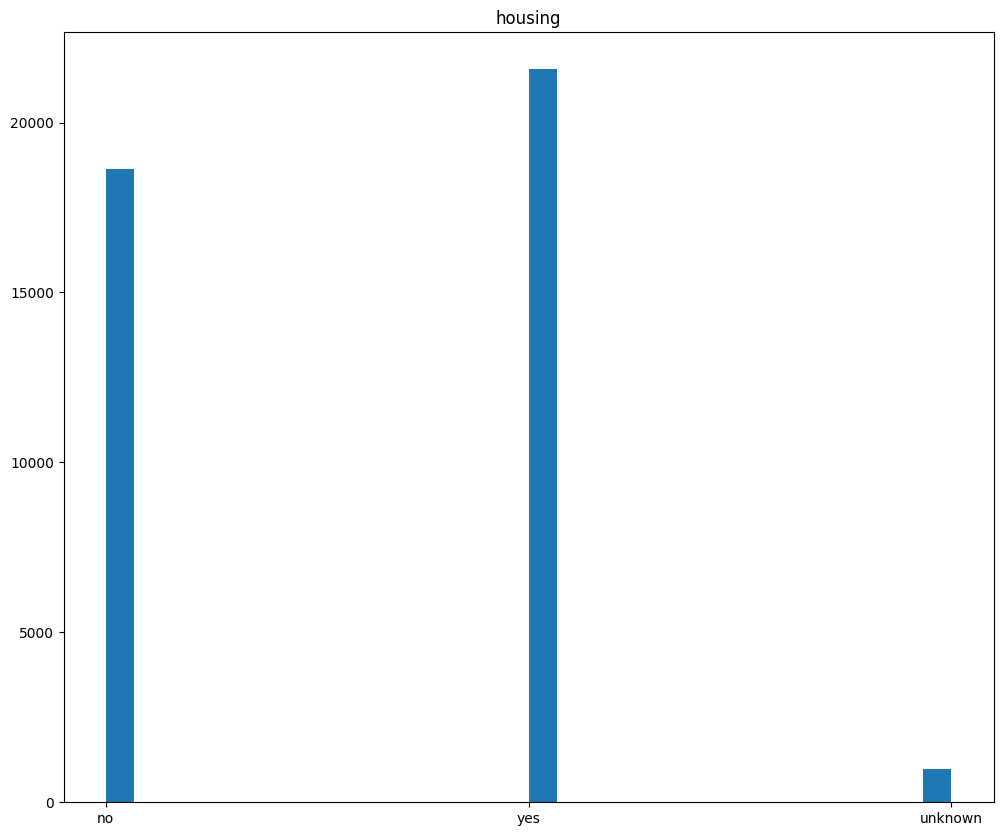

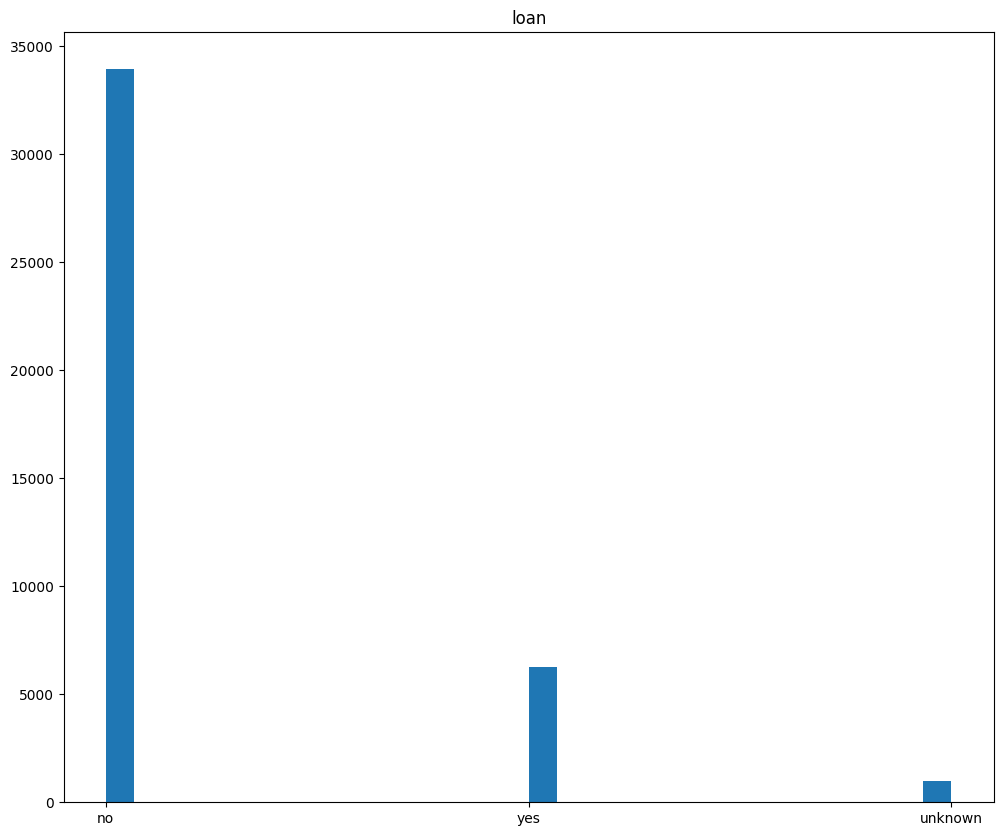

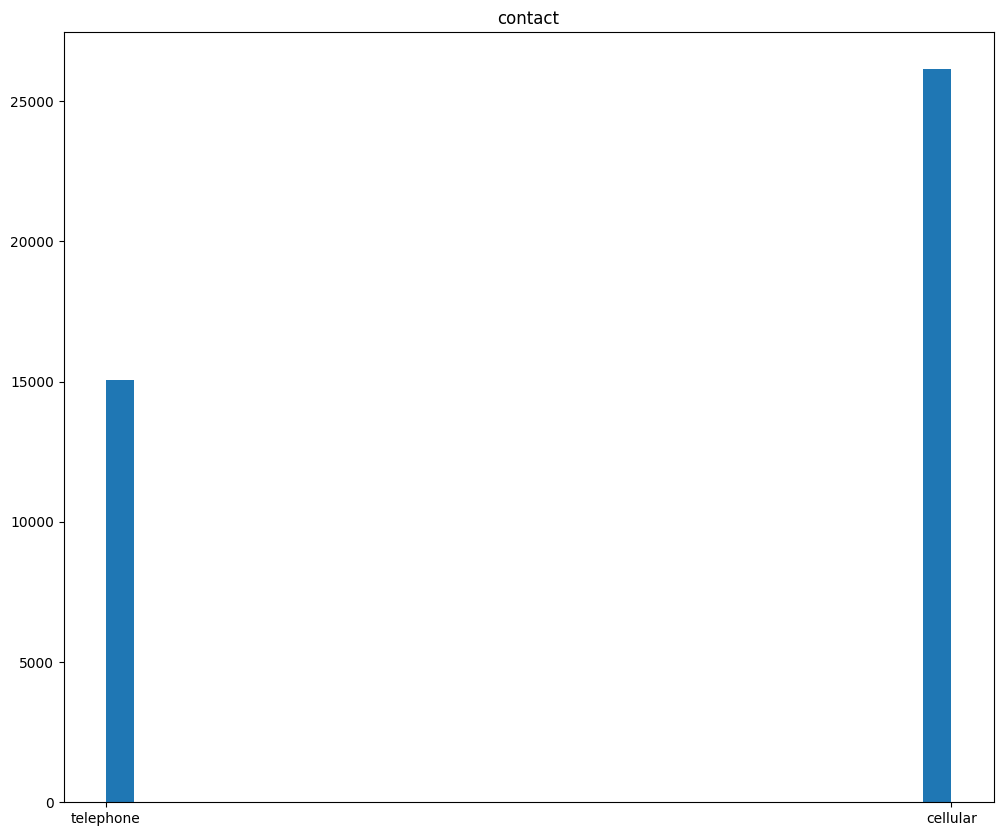

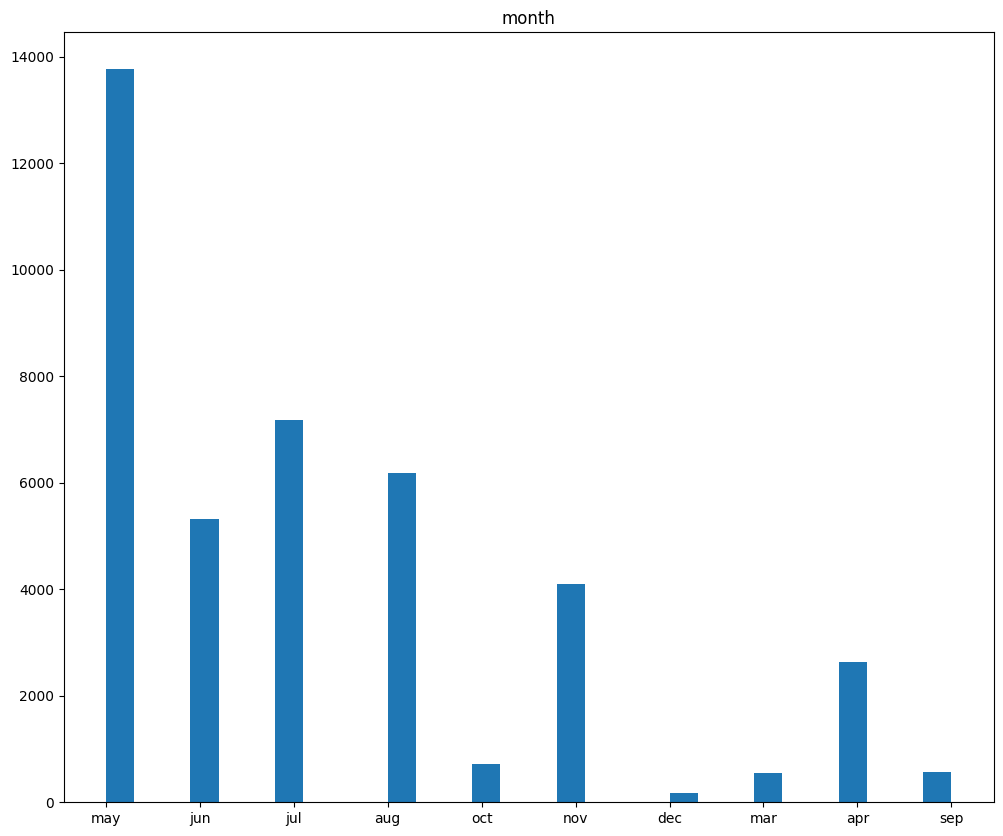

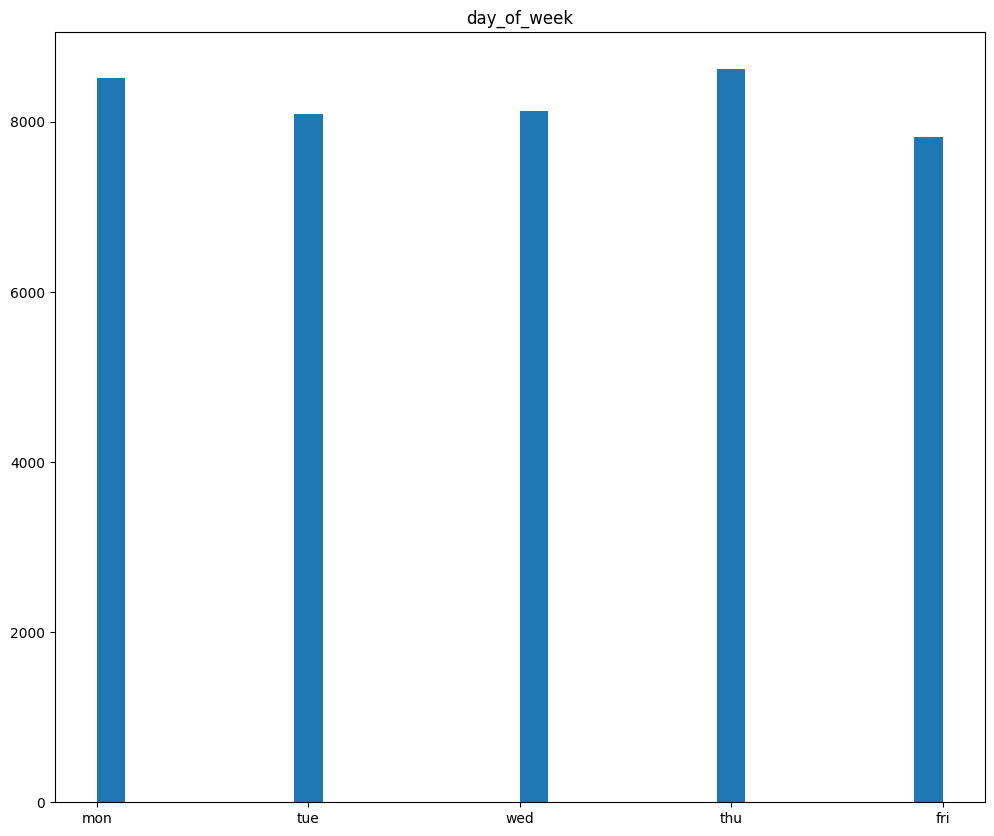

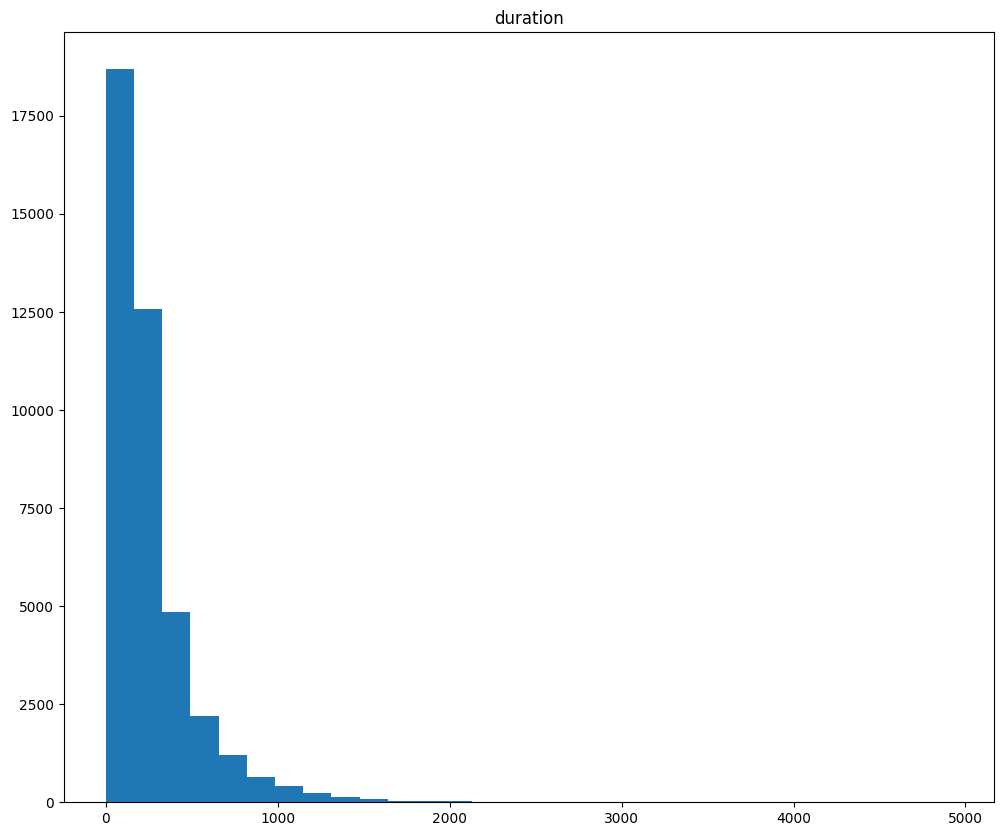

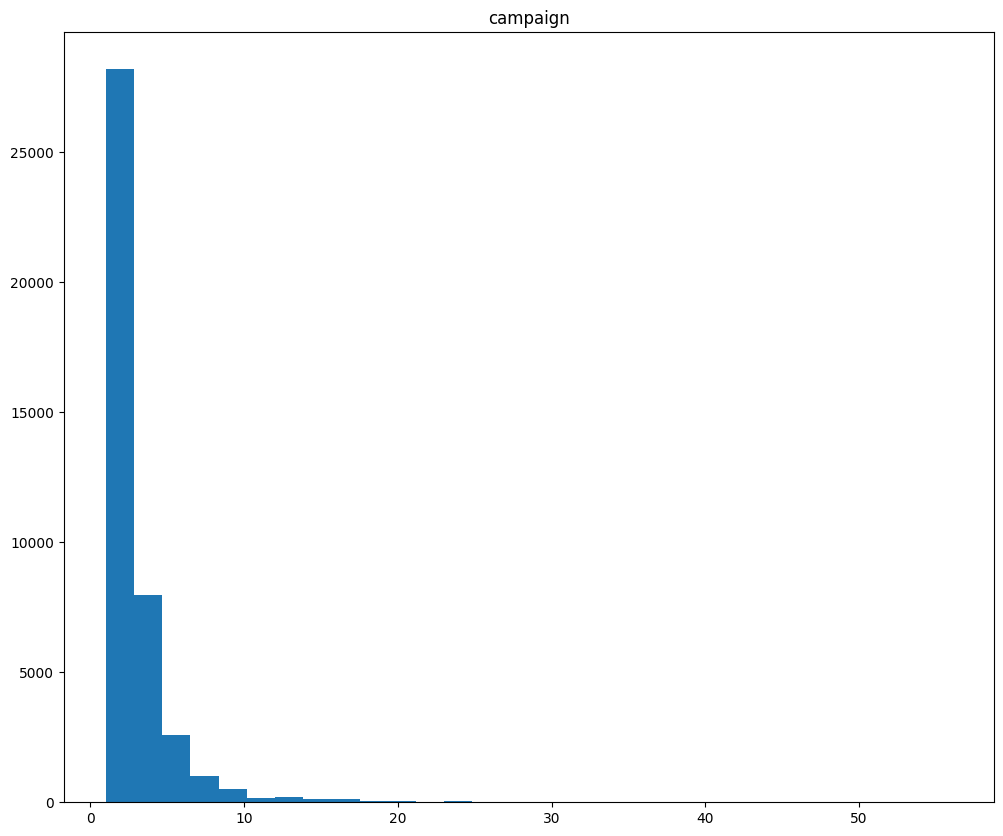

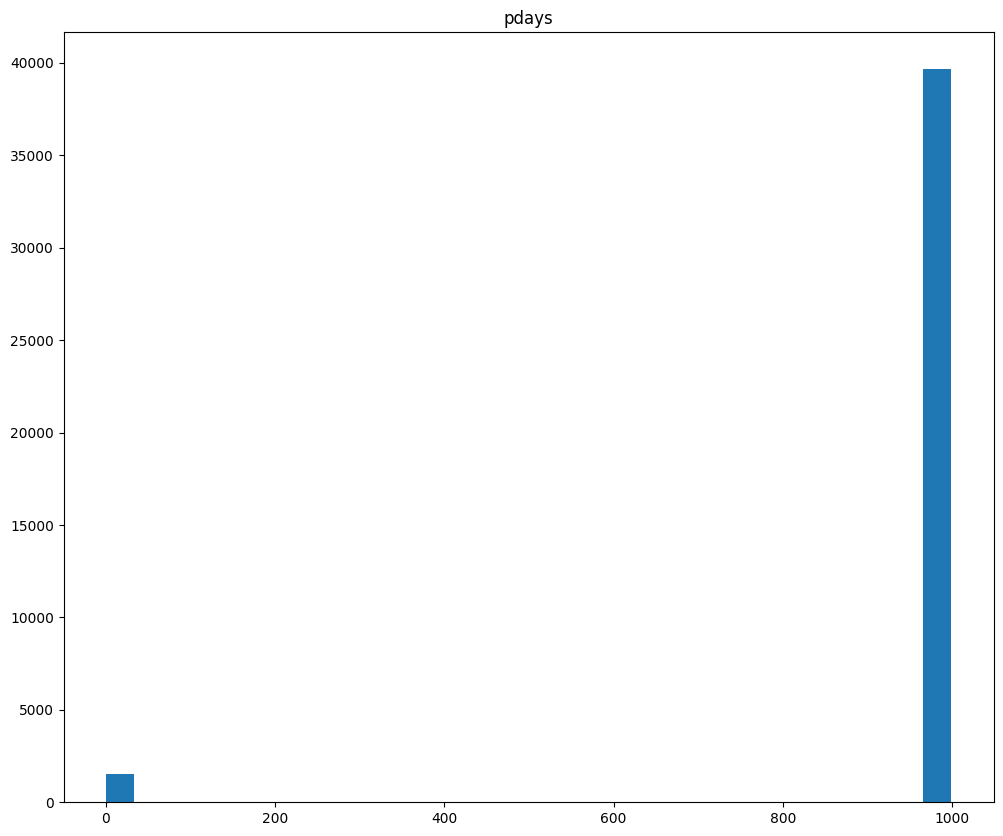

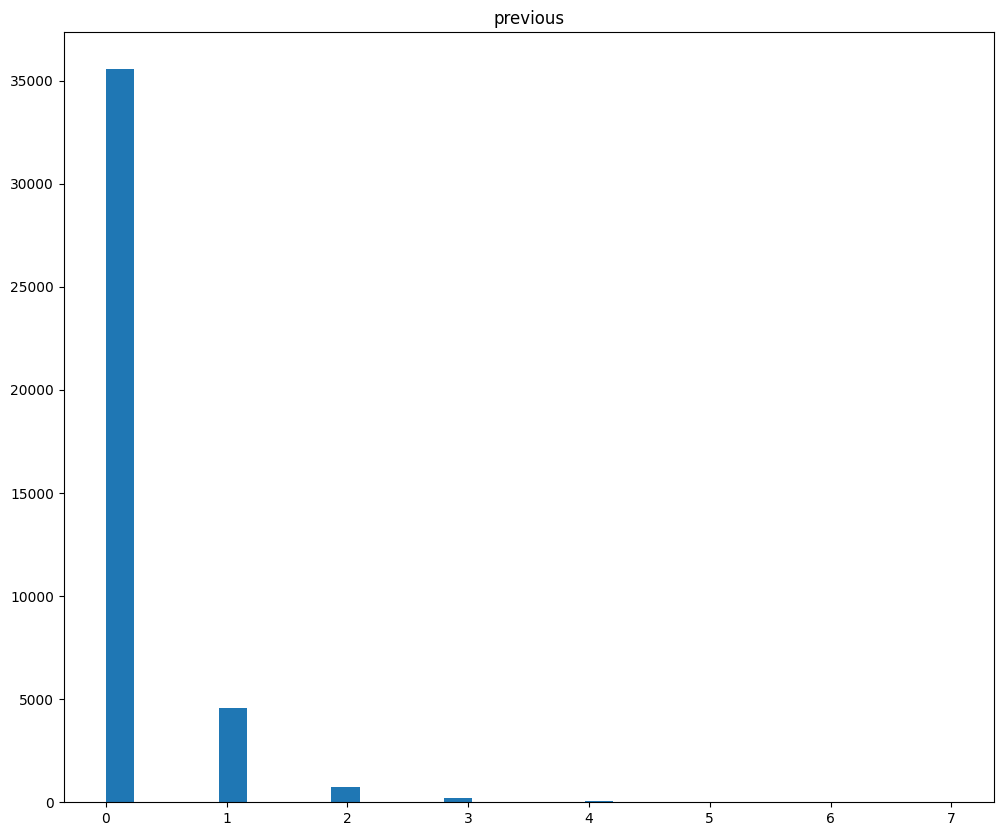

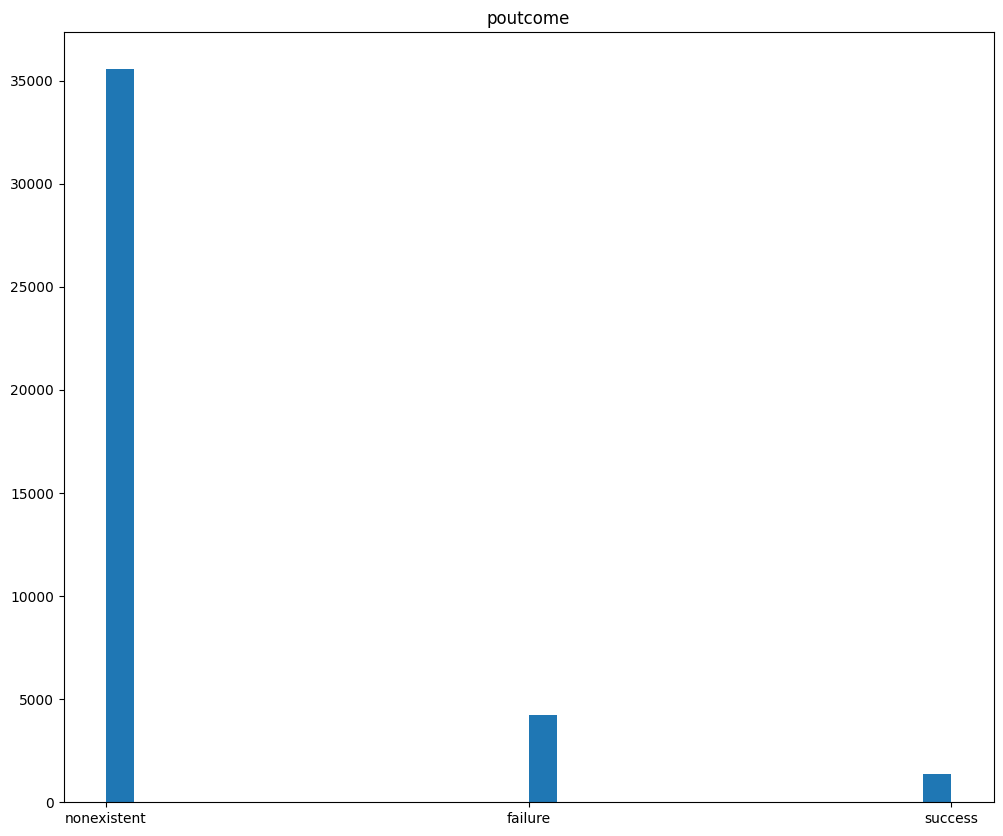

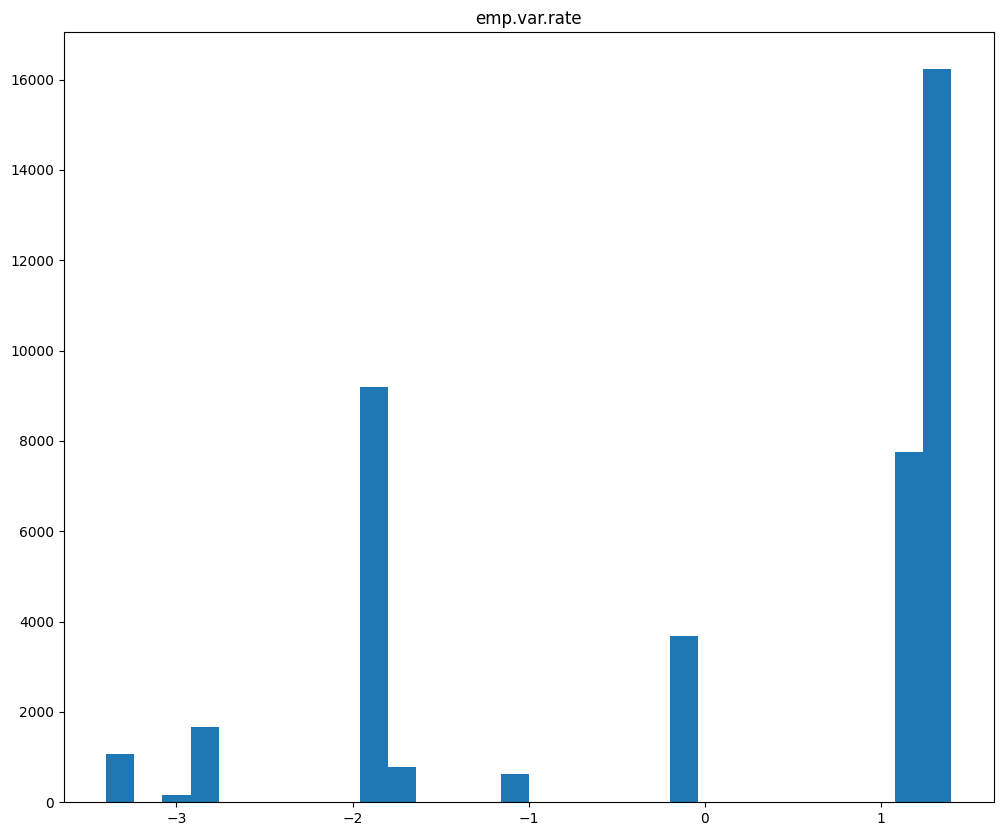

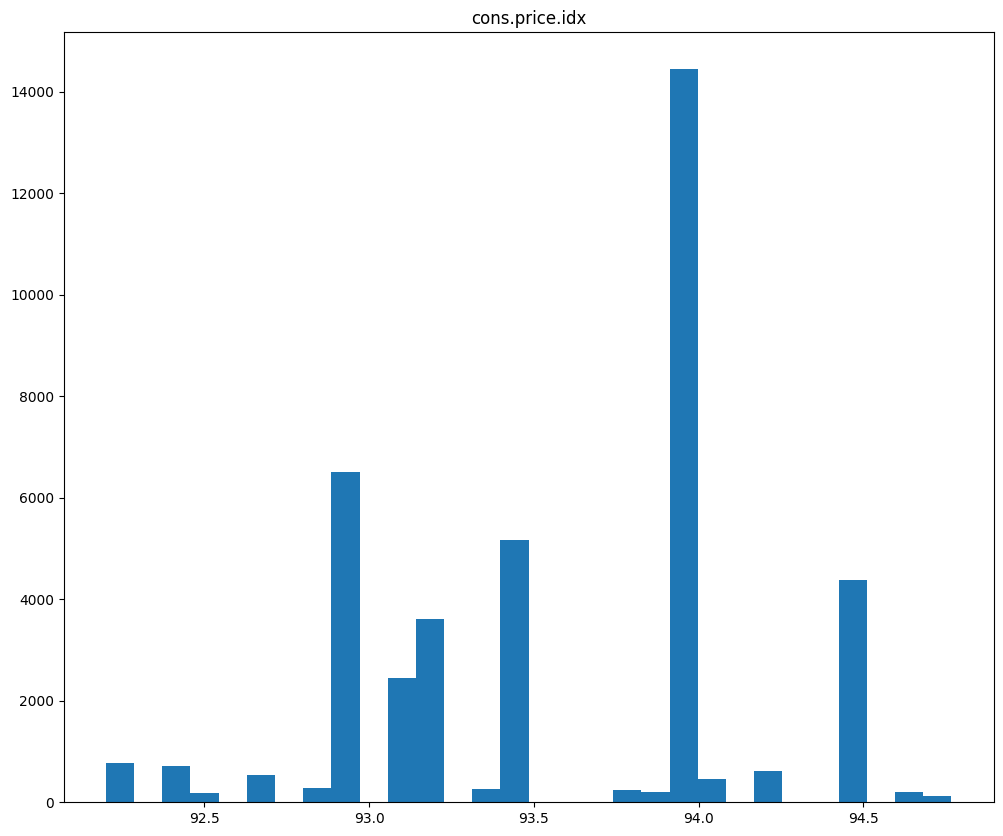

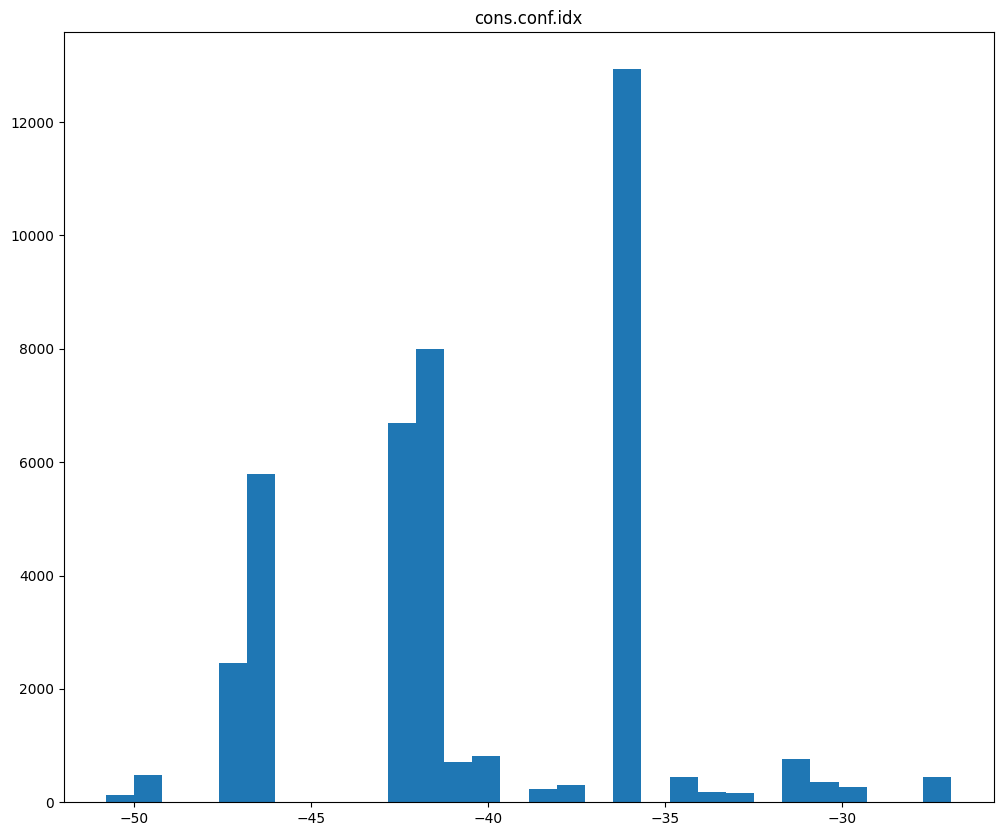

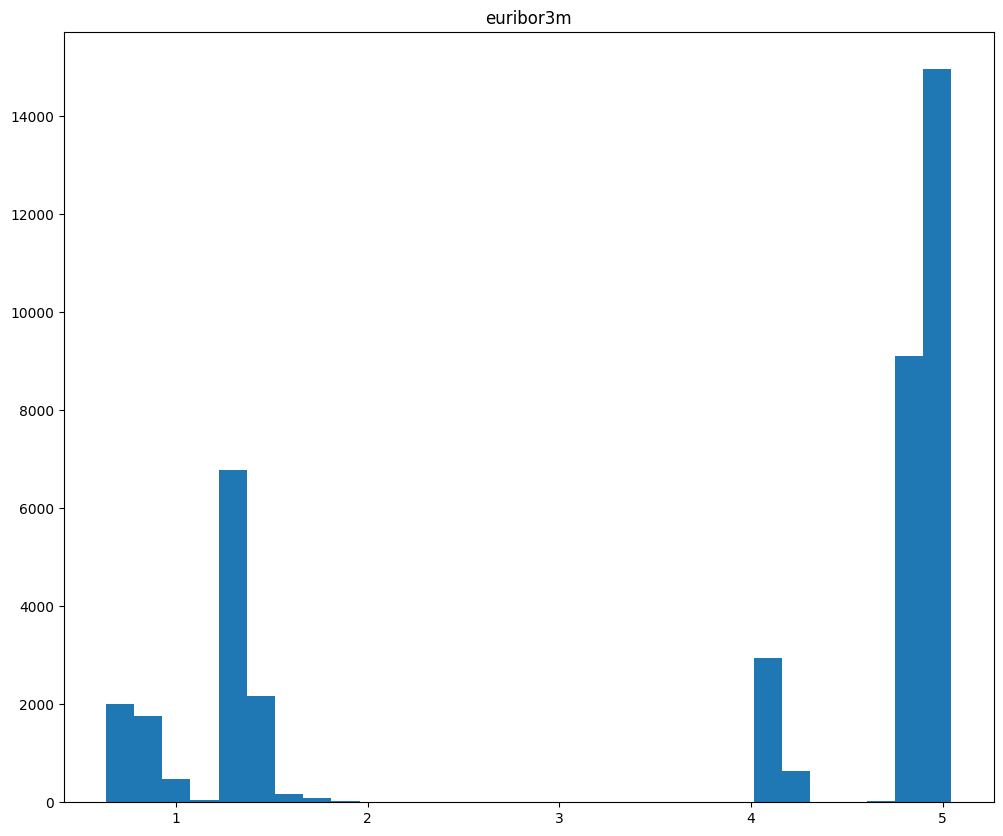

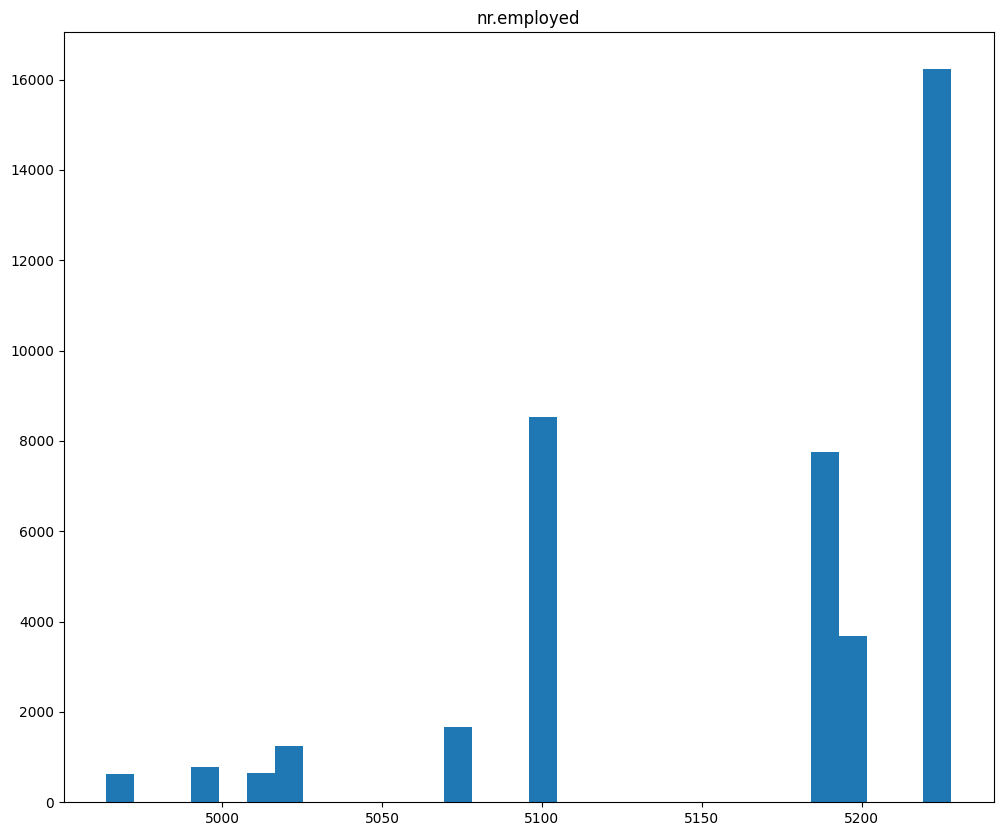

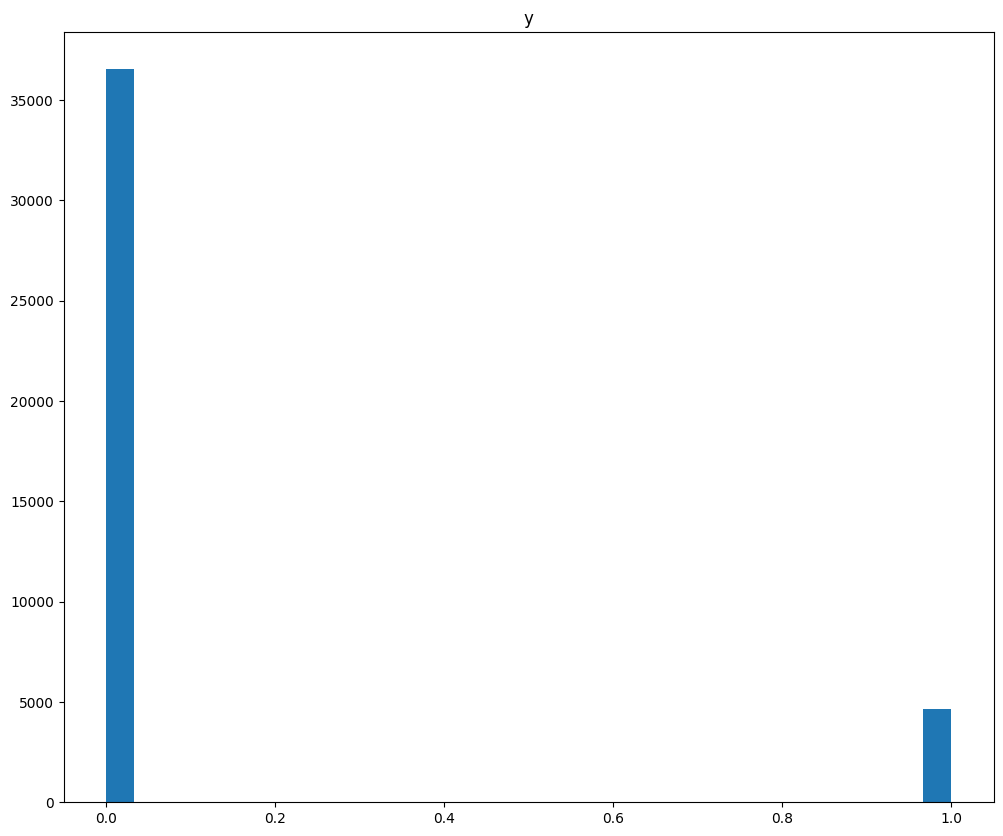

In [9]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(12,10))
    ax.hist(df[col],bins=30)
    ax.set_title(col)


Histogramy względem klas

<ipython-input-11-ef1c8888e02c>:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,8))


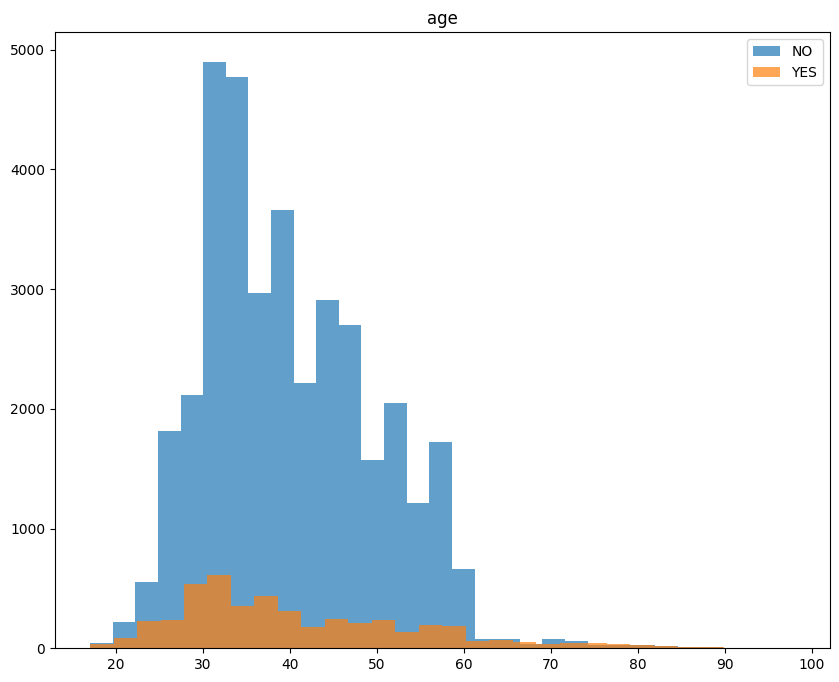

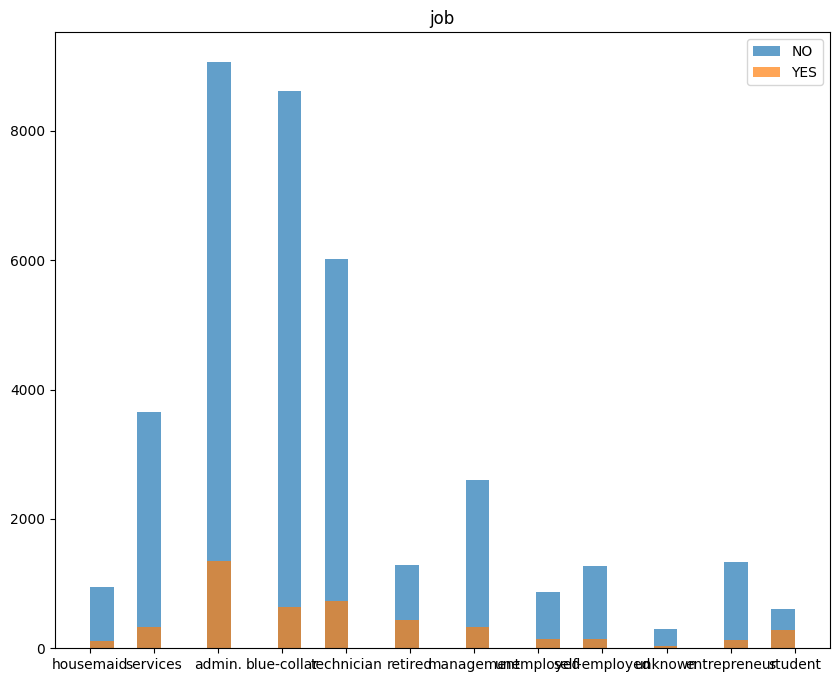

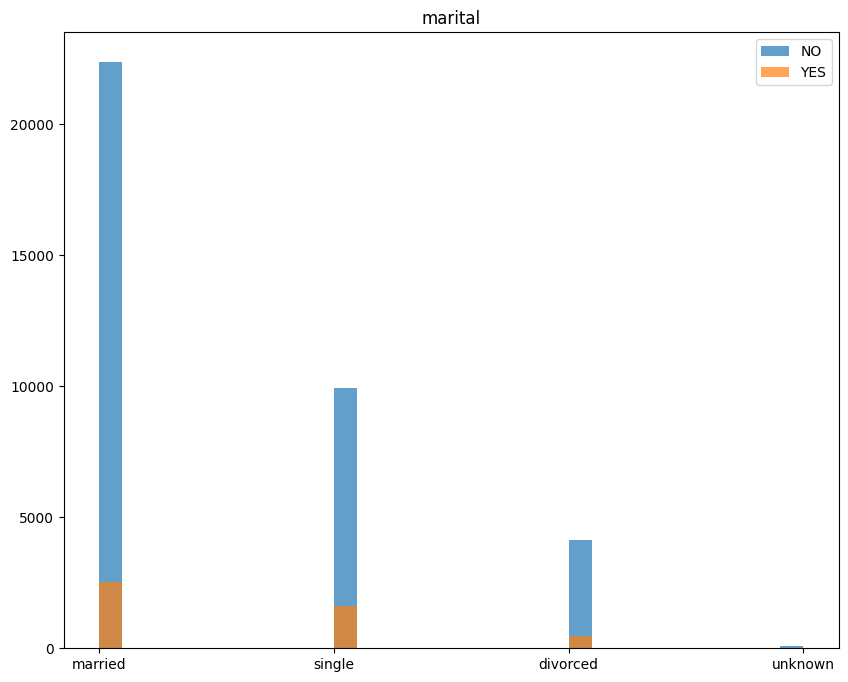

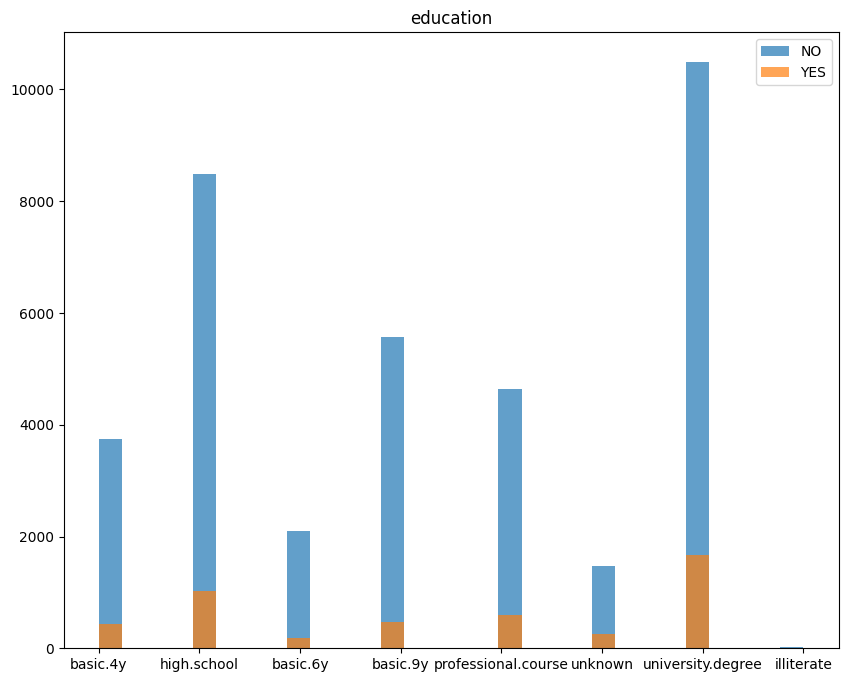

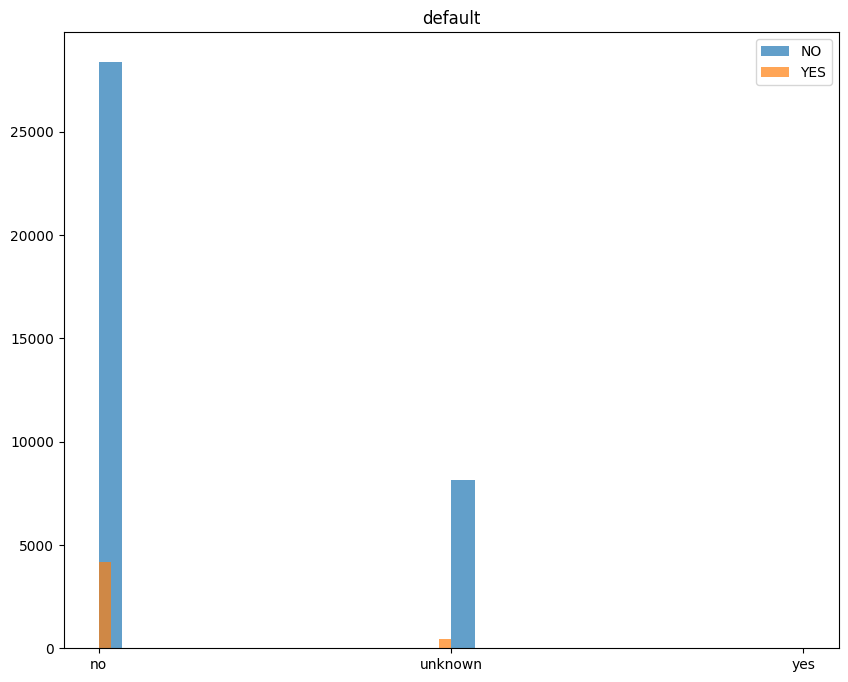

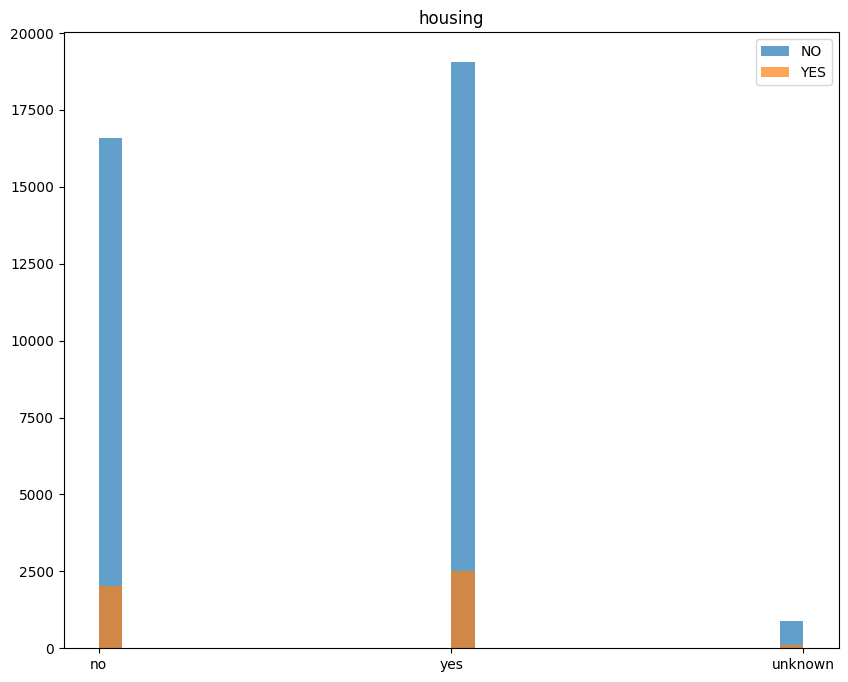

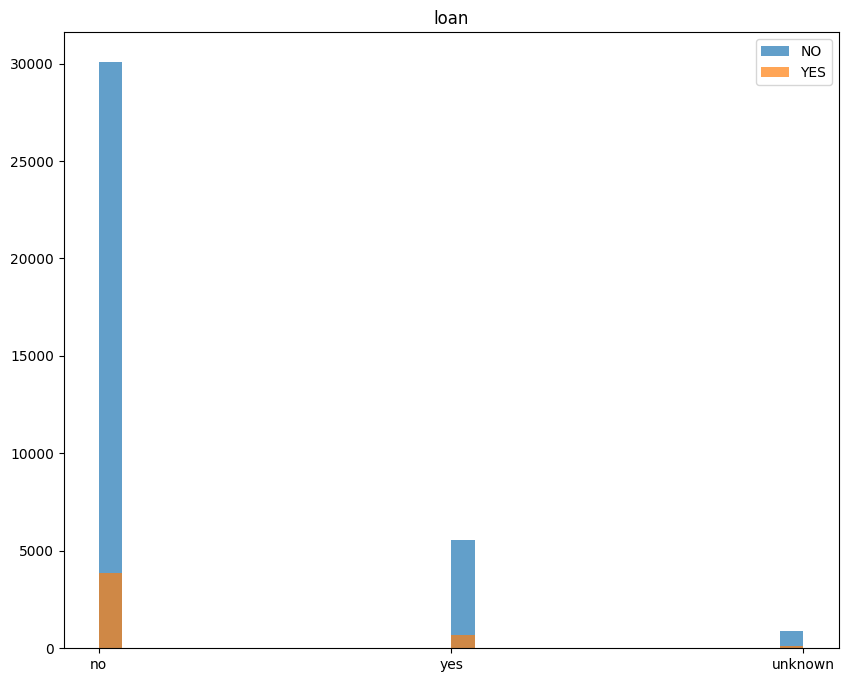

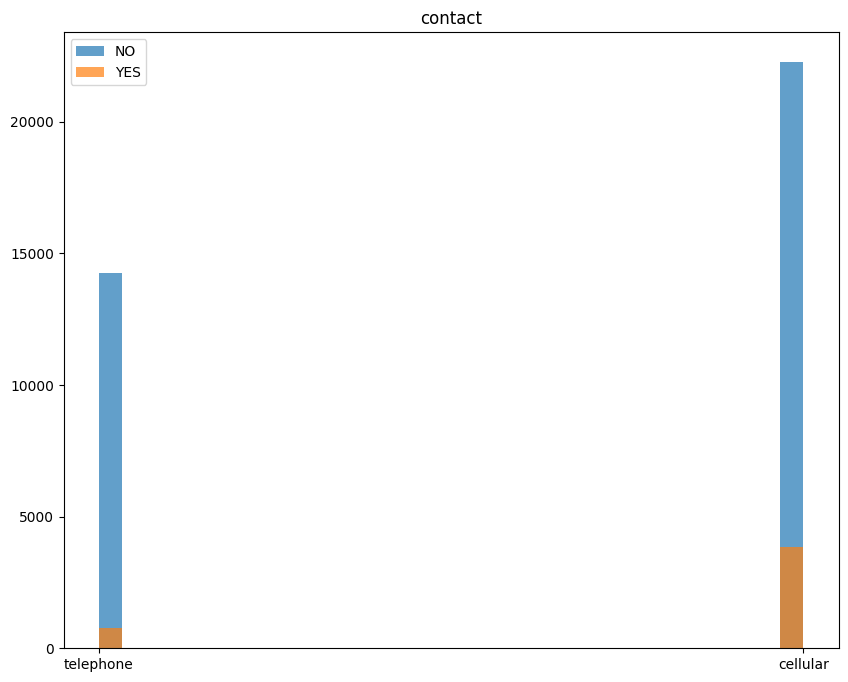

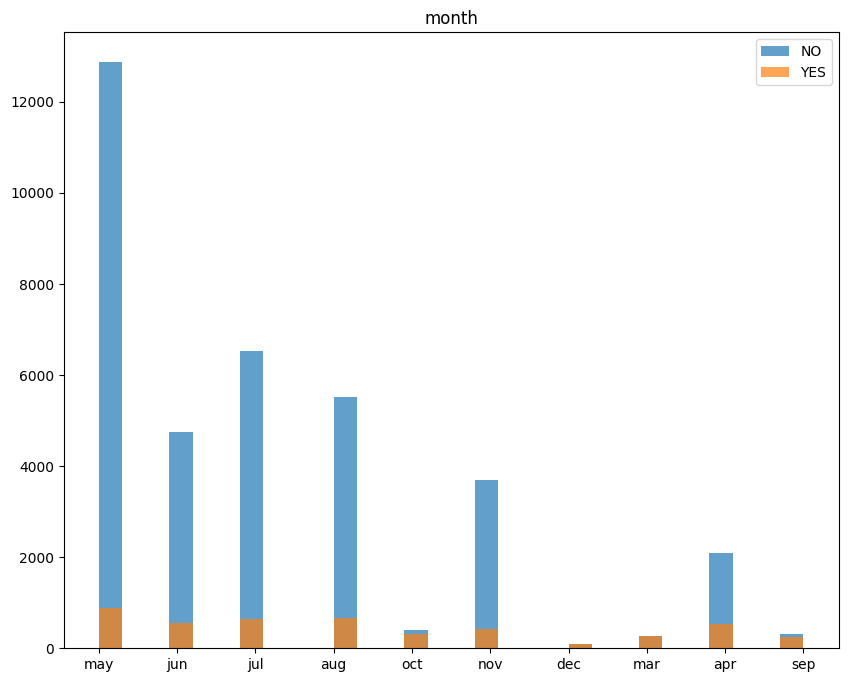

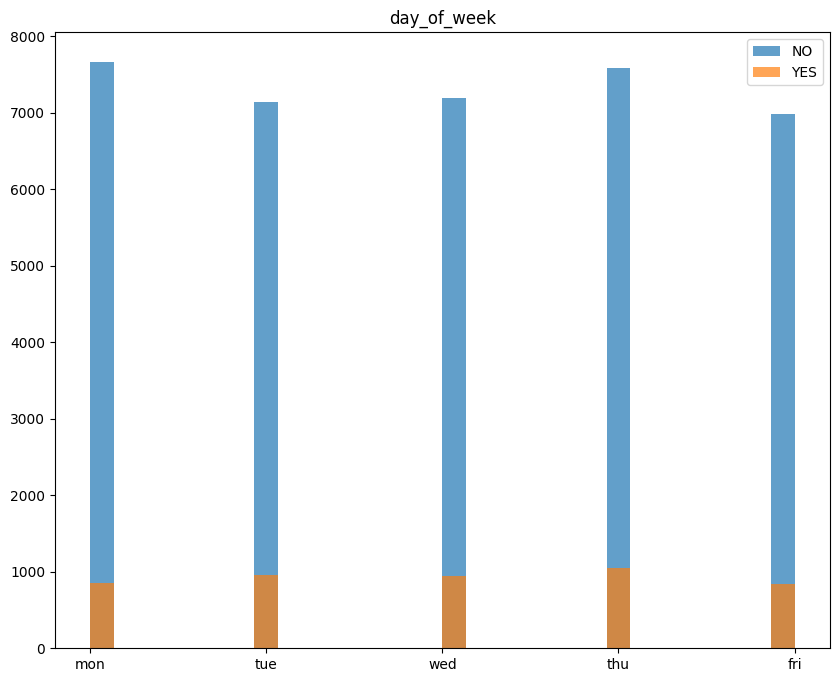

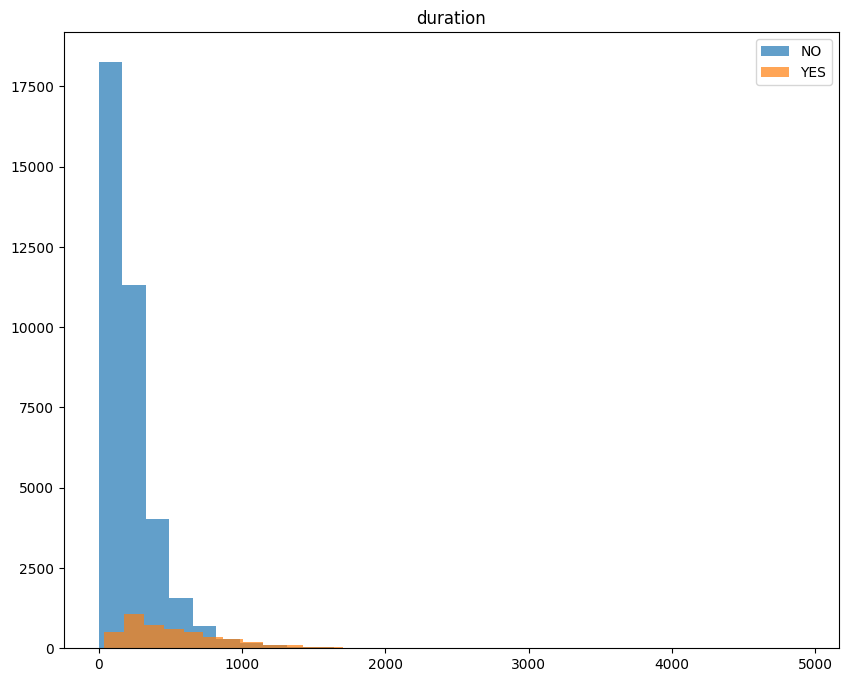

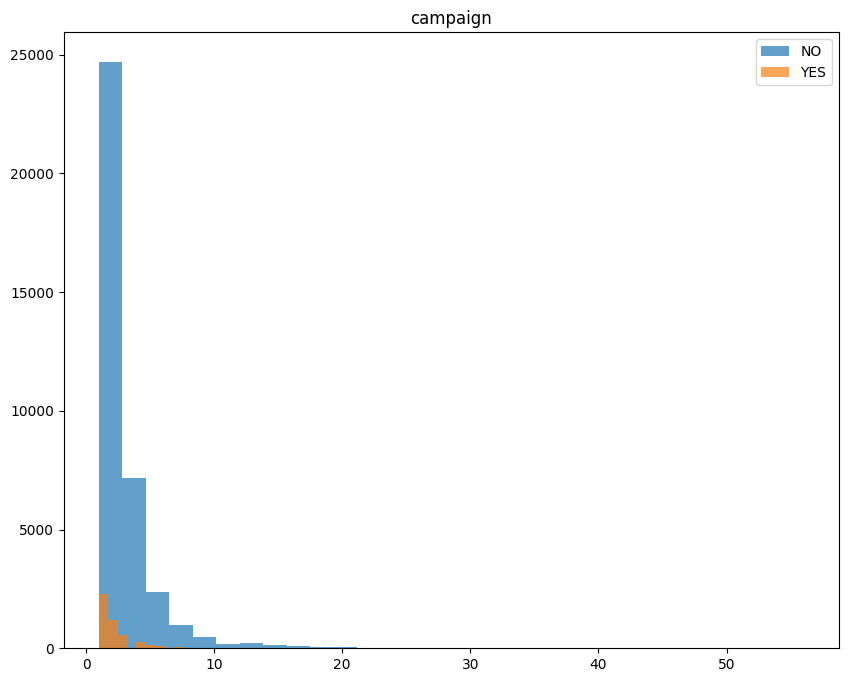

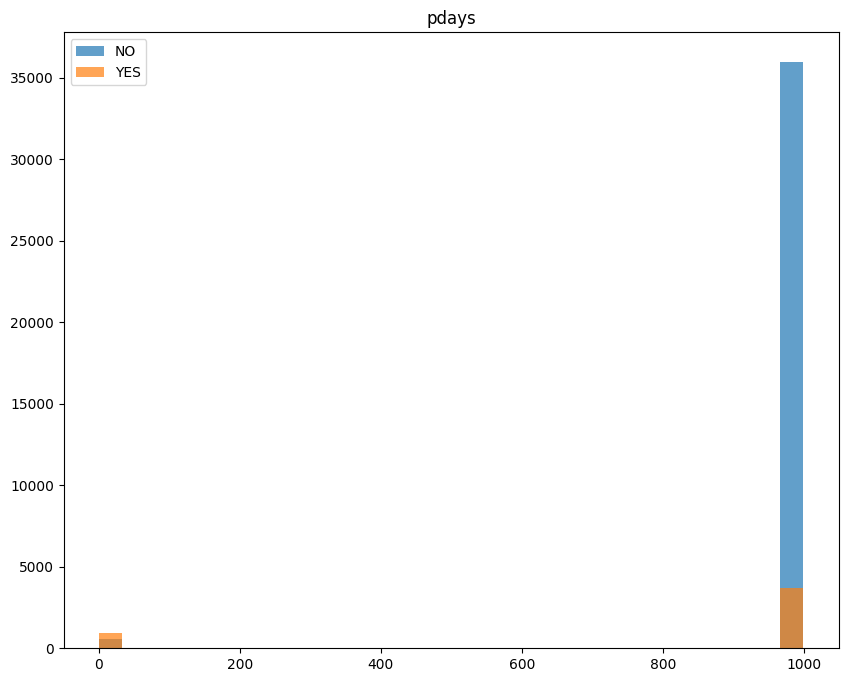

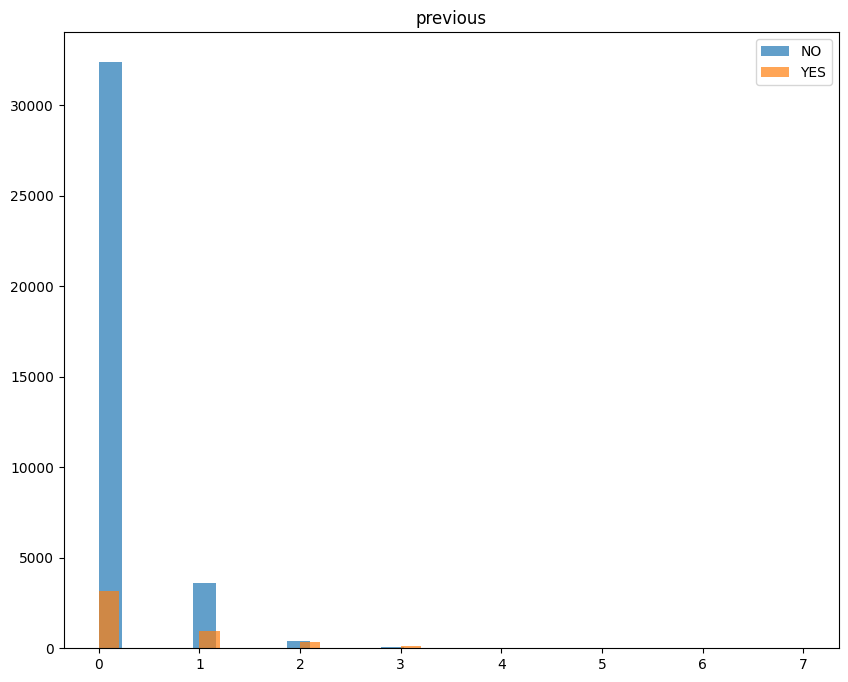

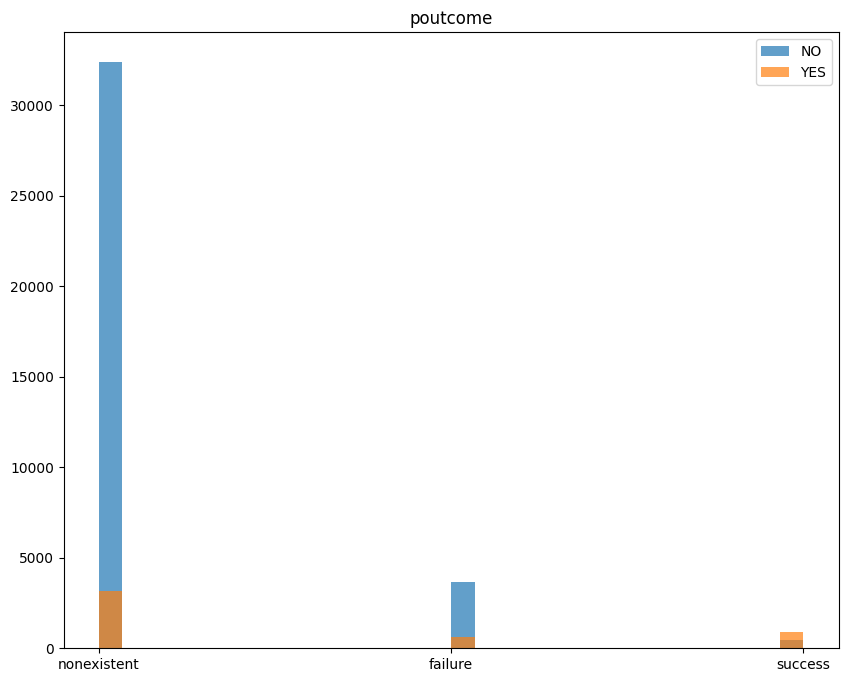

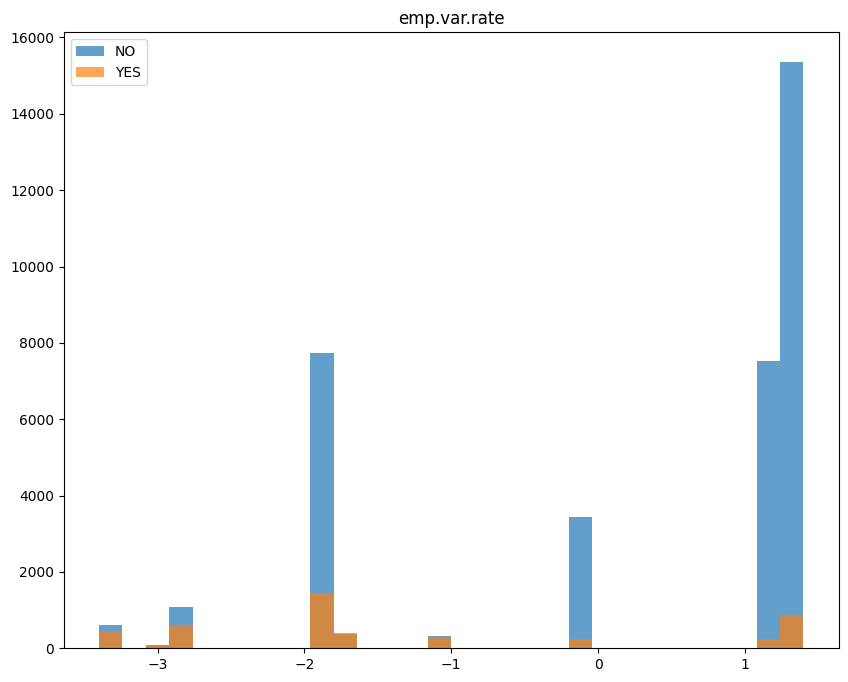

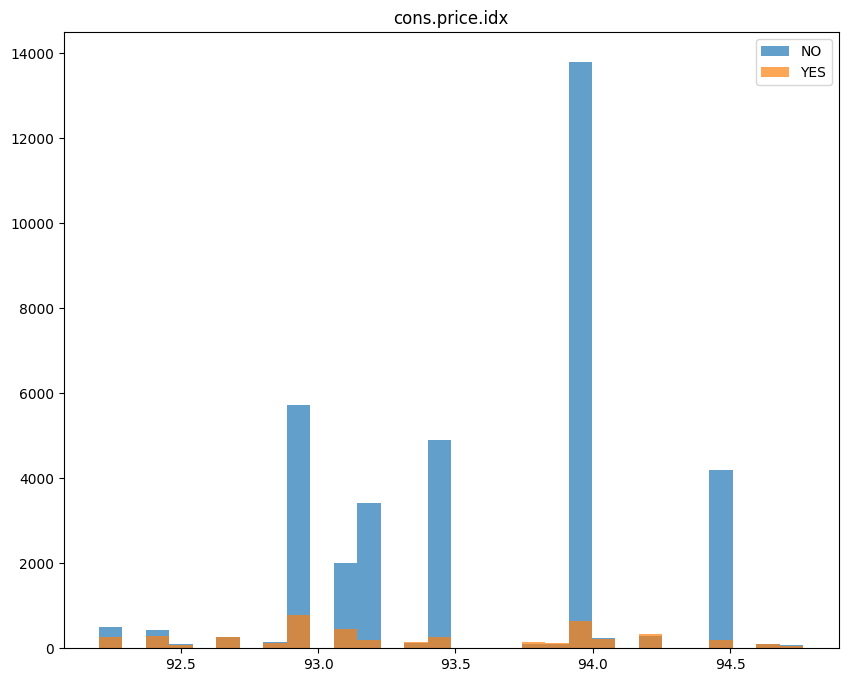

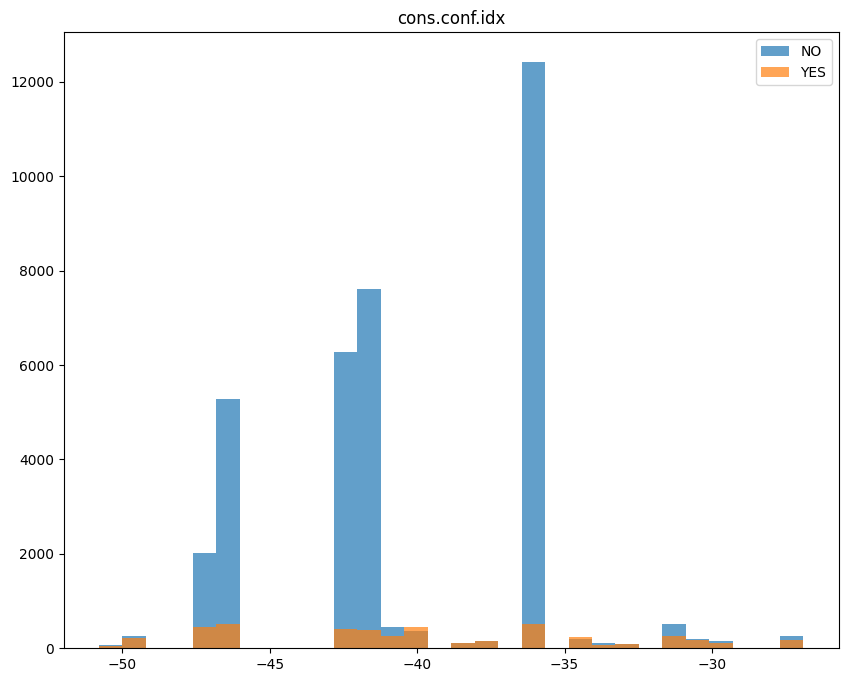

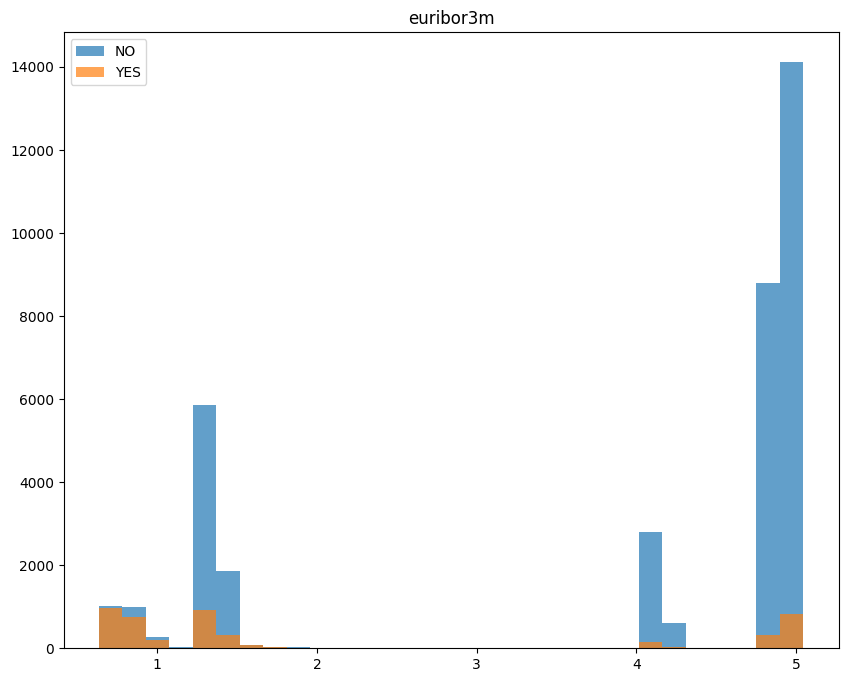

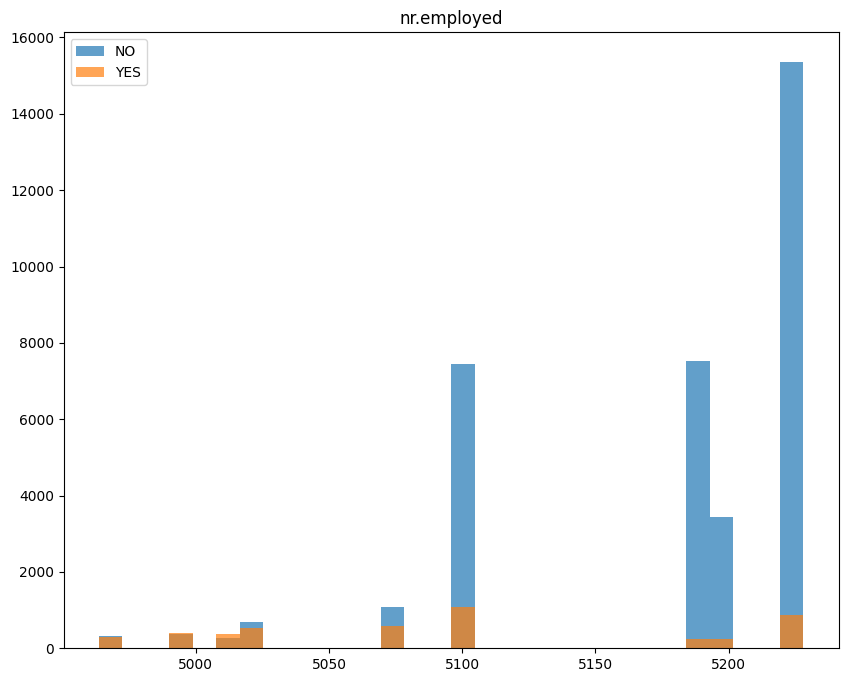

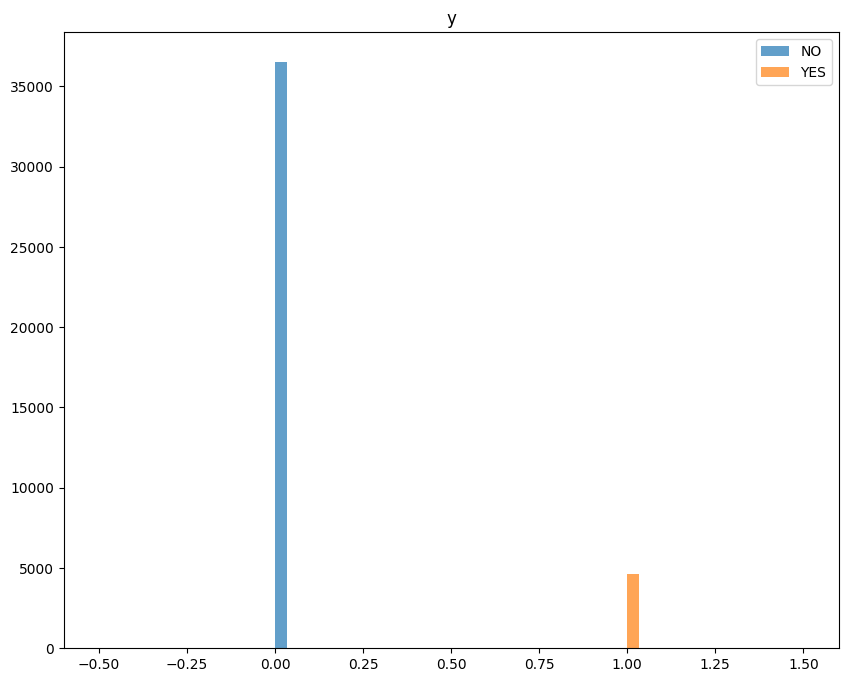

In [ ]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(10,8))
    cl0 = df.loc[df["y"]==0,col]
    cl1 = df.loc[df["y"]==1,col]
    ax.hist(cl0,bins=30, alpha=0.7, label="NO")
    ax.hist(cl1,bins=30, alpha=0.7, label="YES")
    ax.legend()
    ax.set_title(col)

Histogramy względem klas (wspólna skala)

<ipython-input-12-7ba09d778f4e>:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12,12))


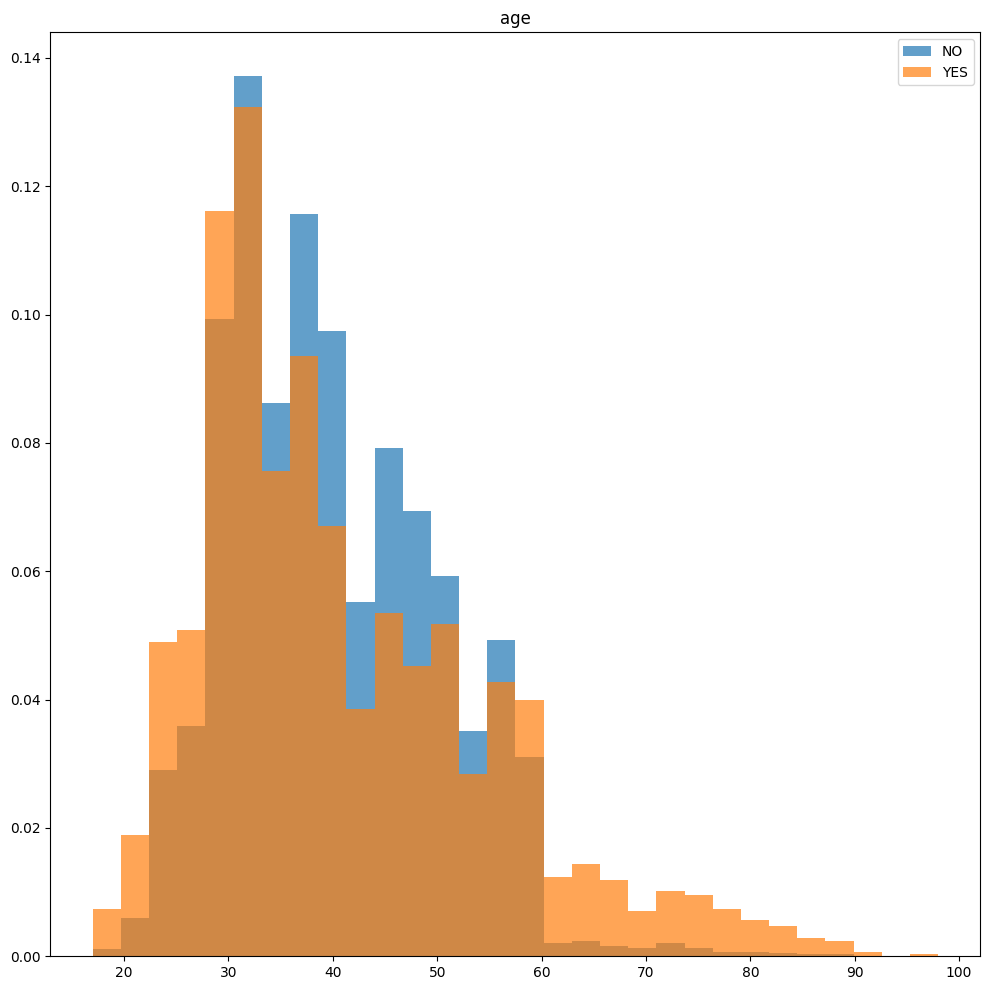

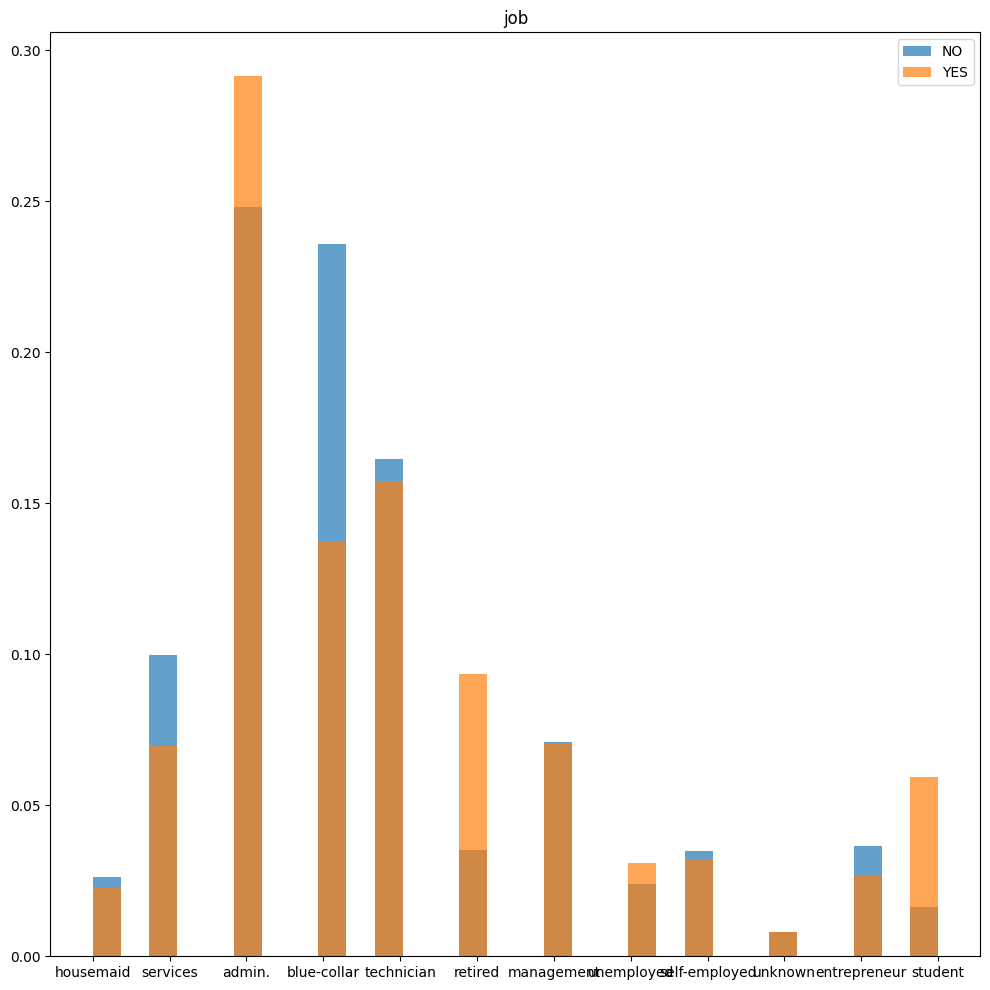

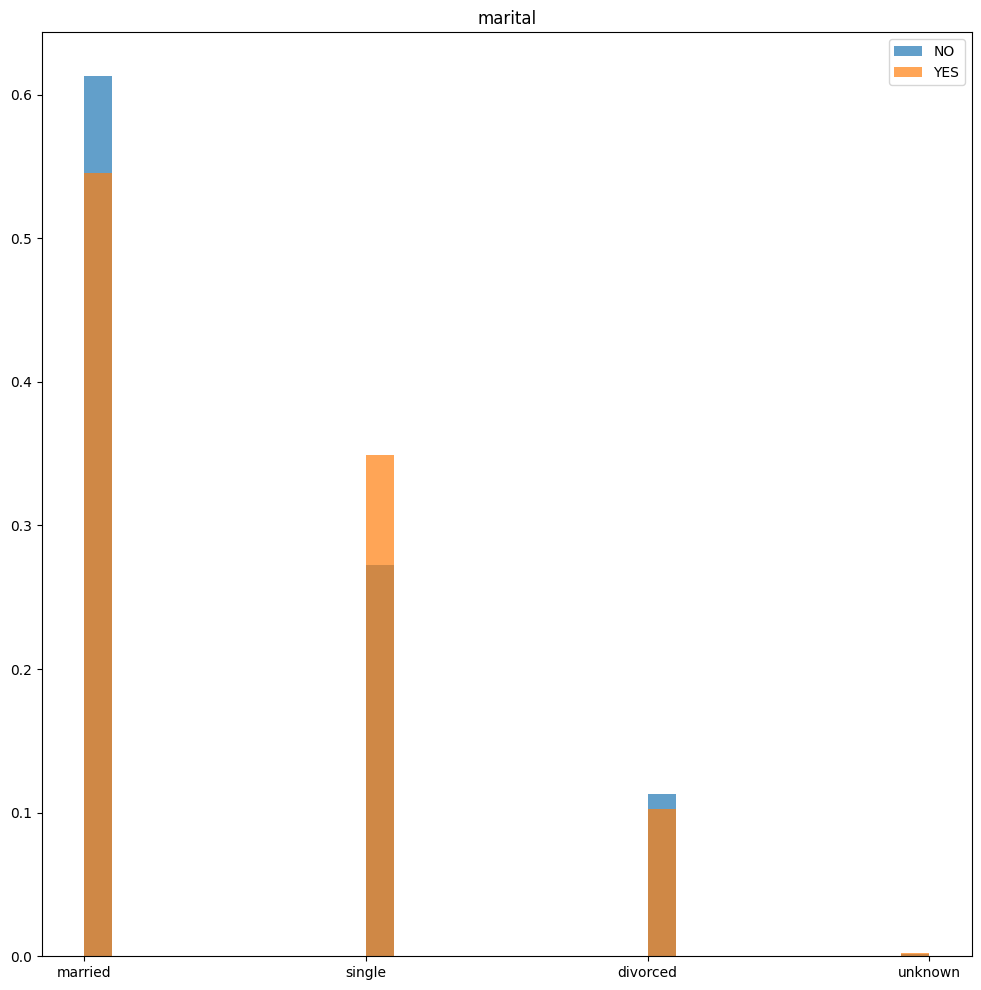

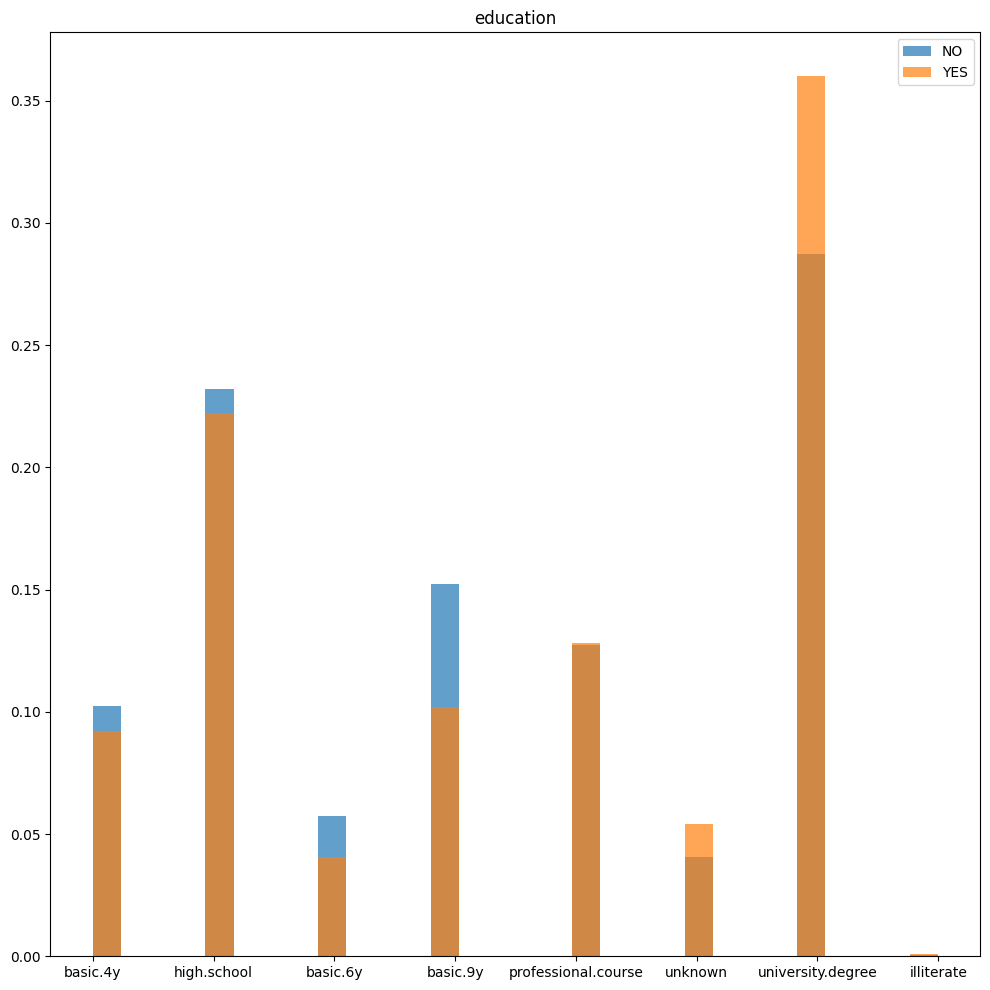

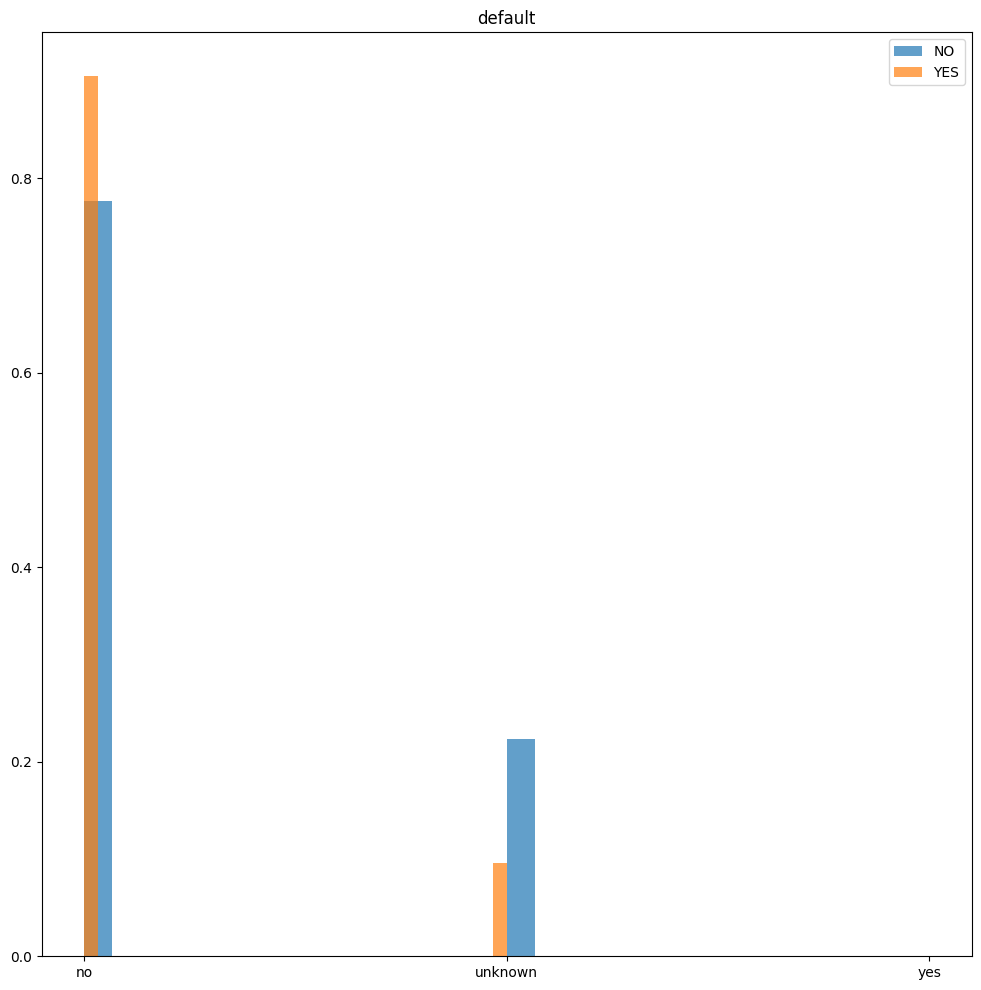

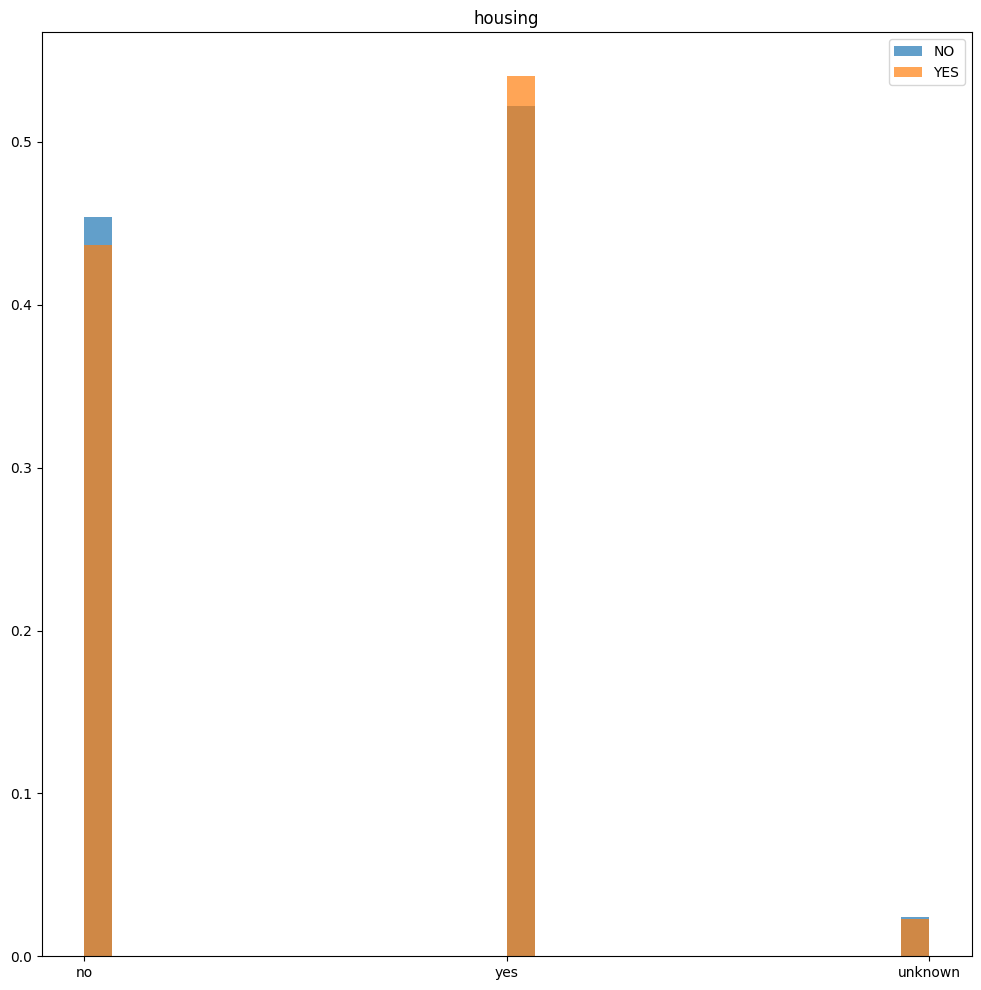

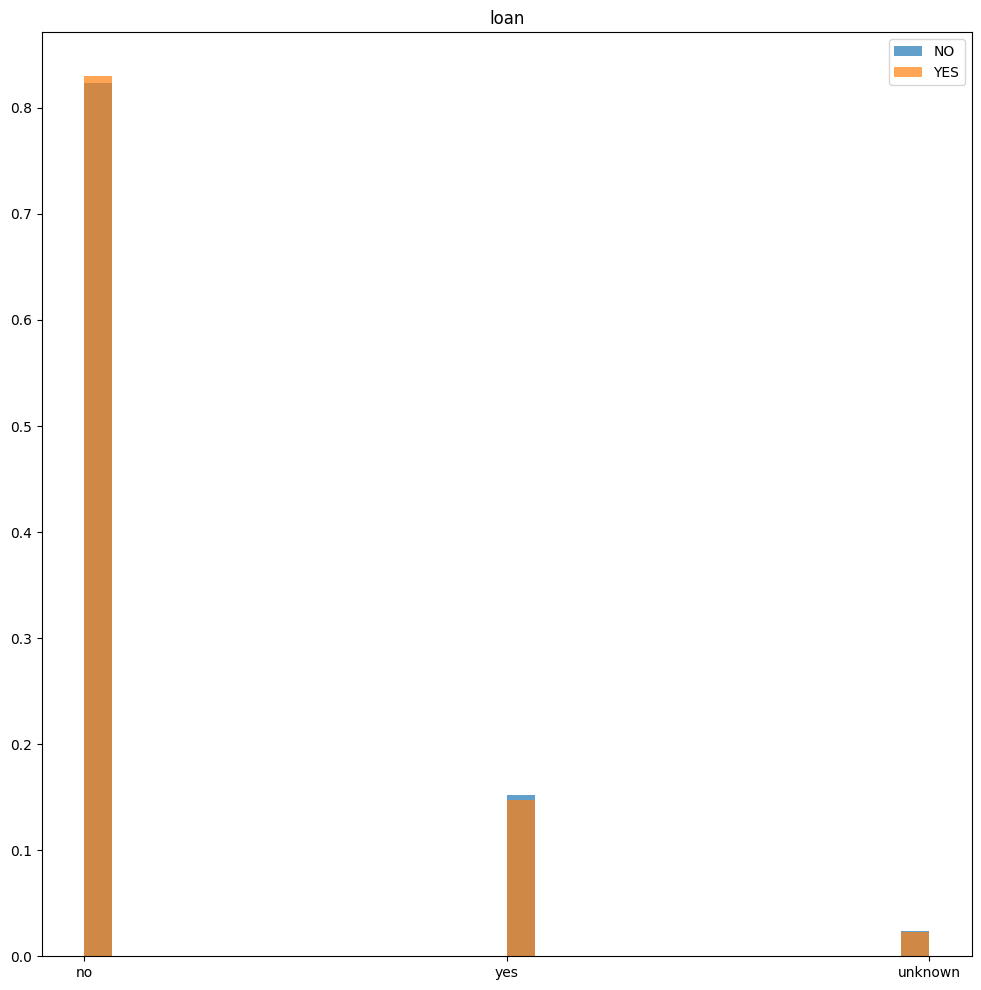

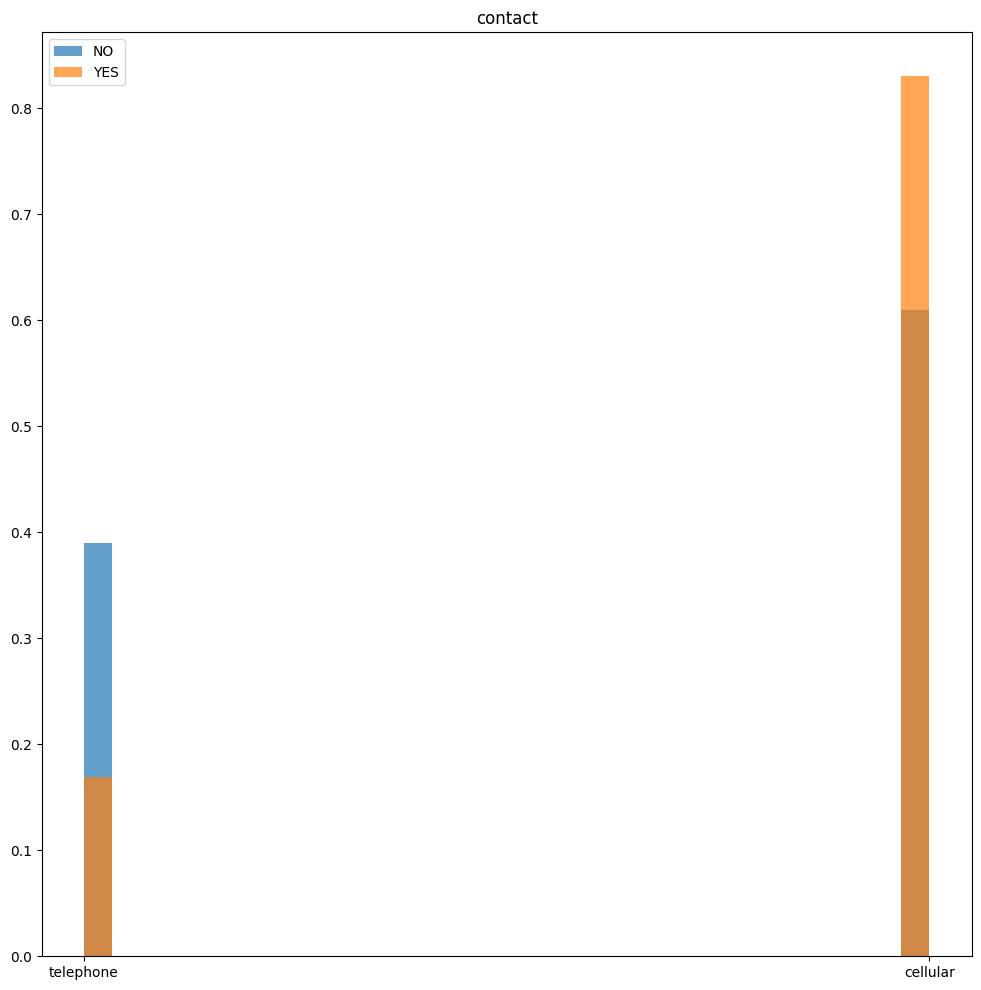

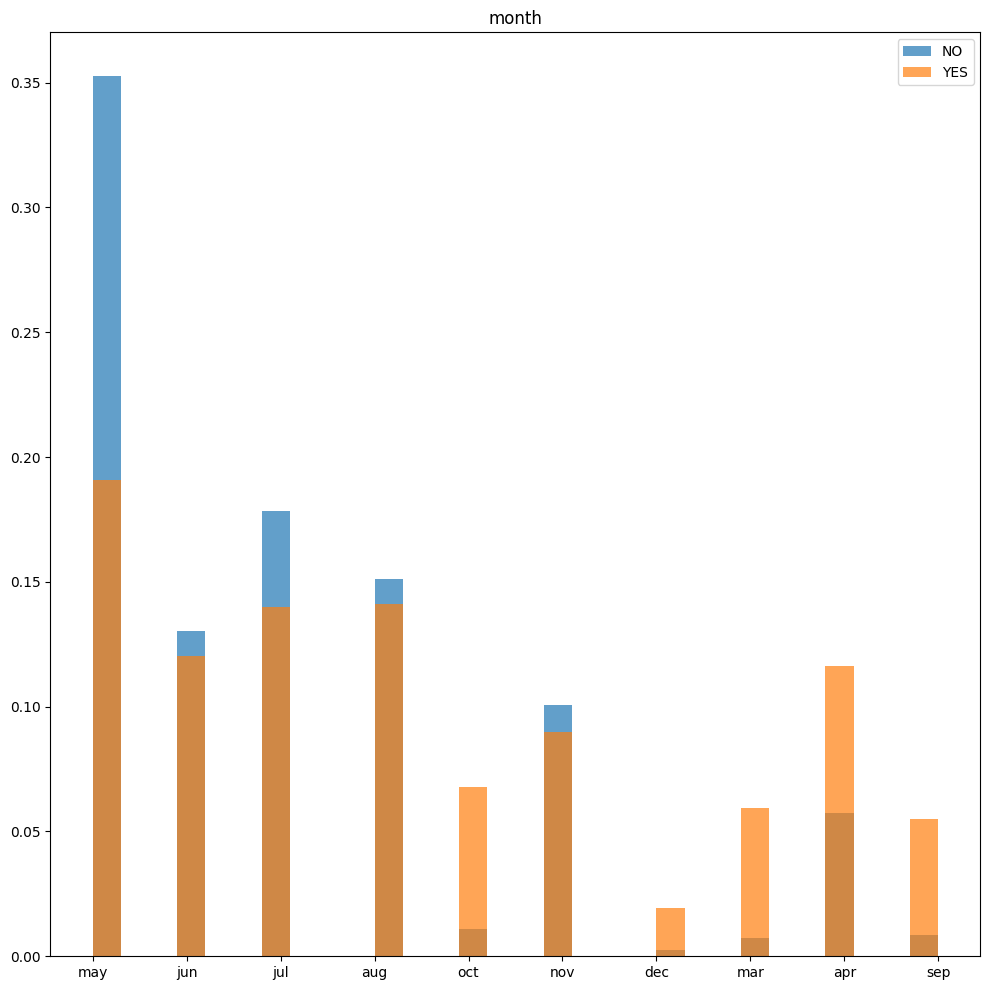

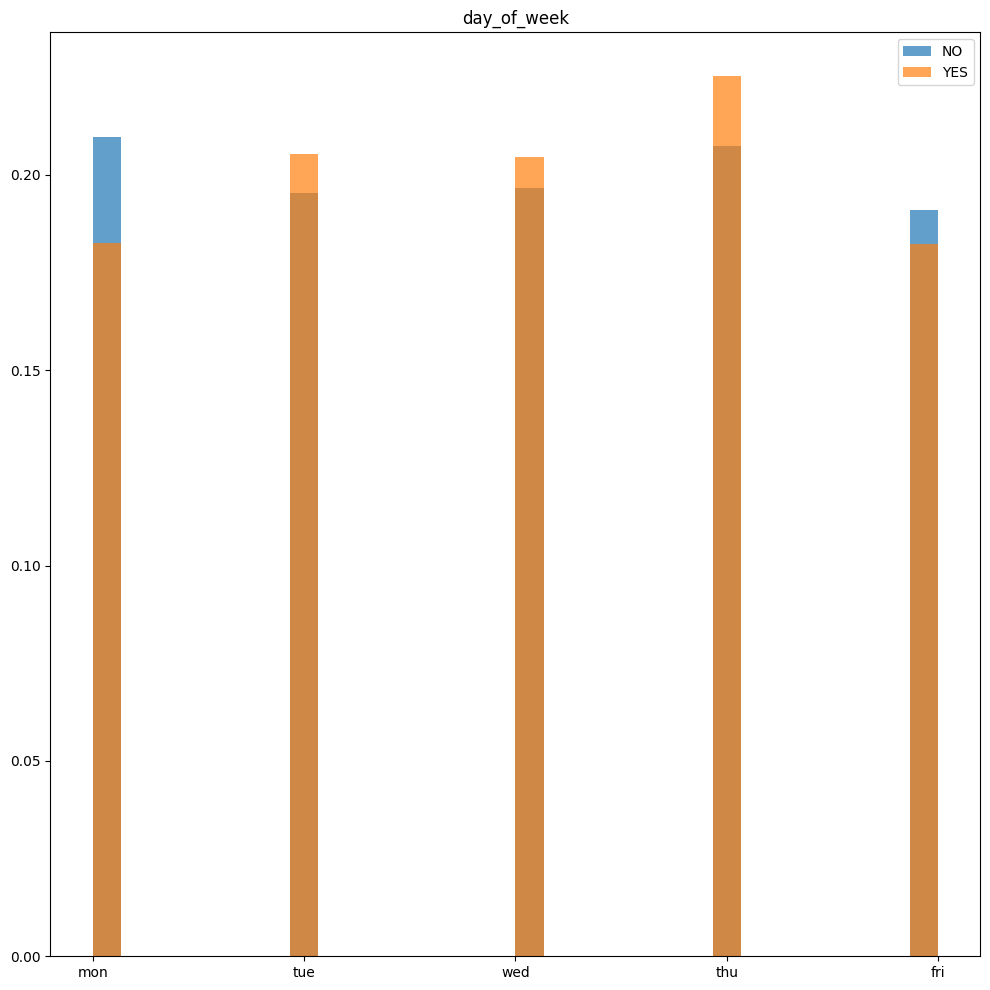

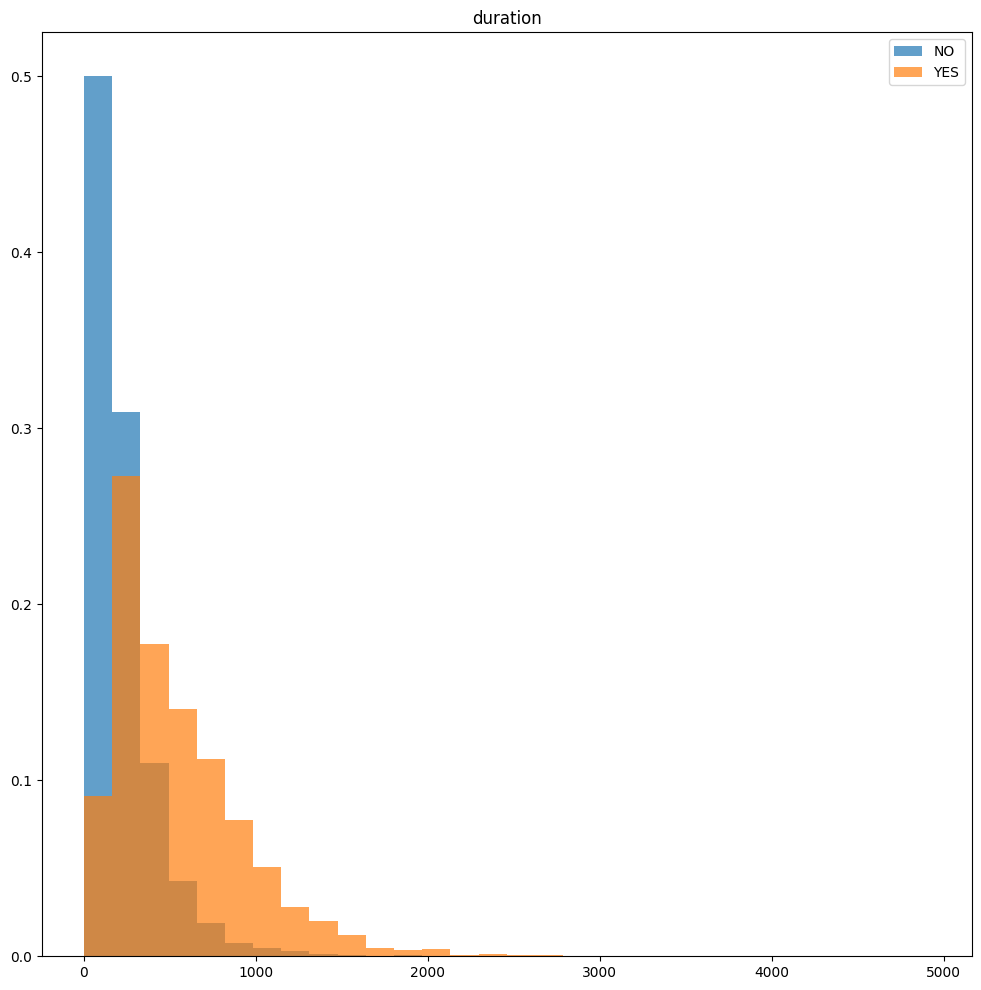

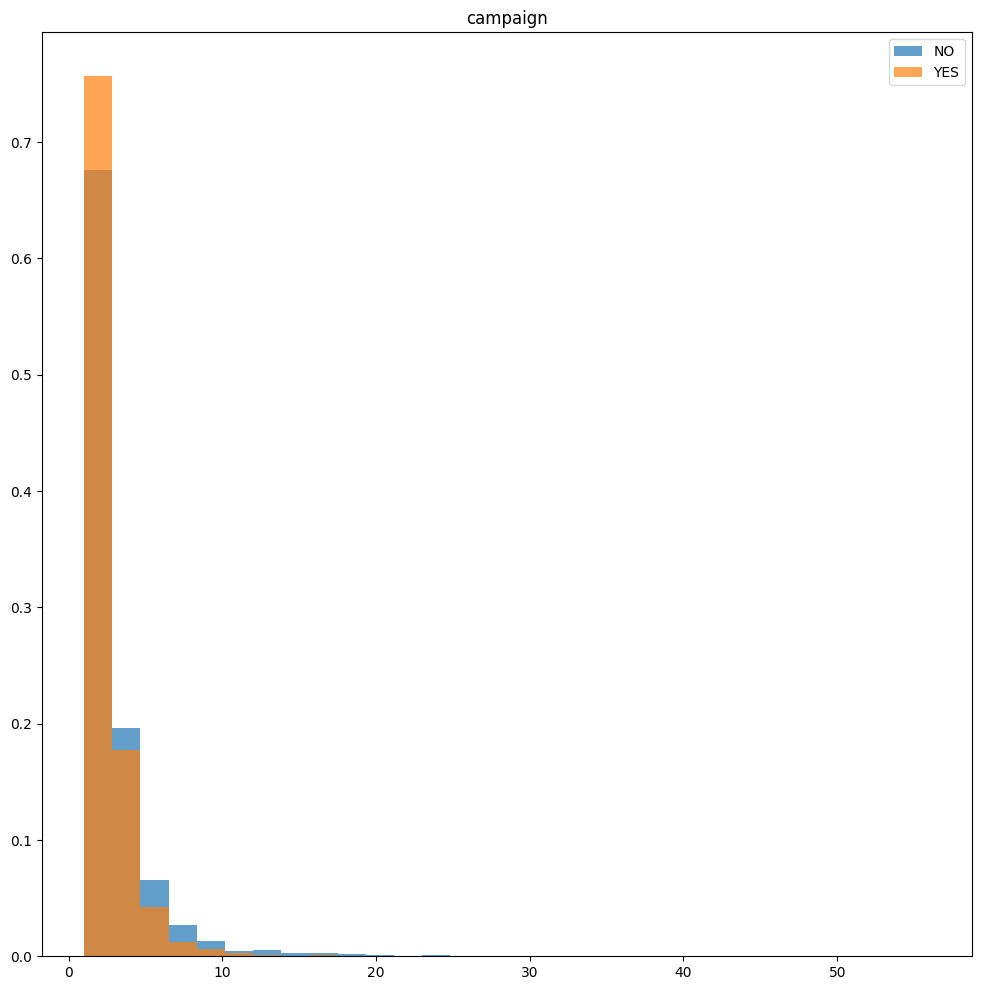

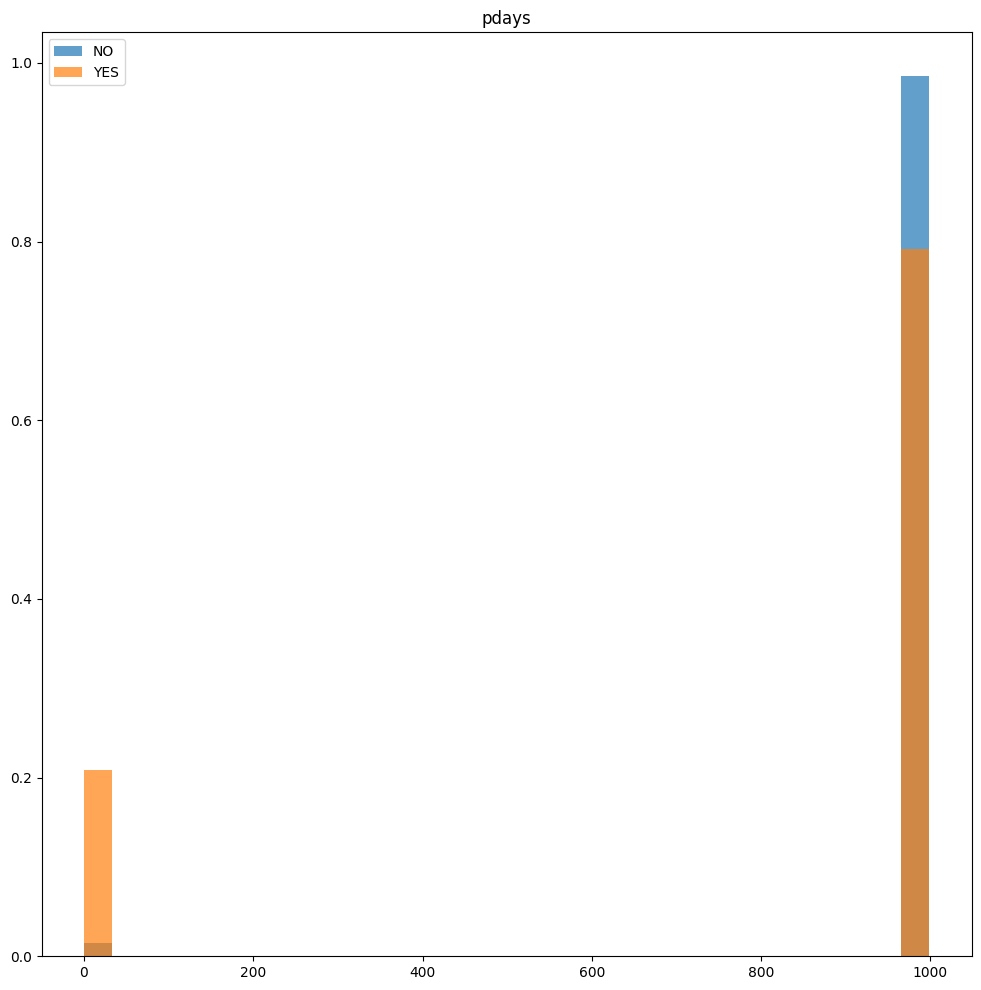

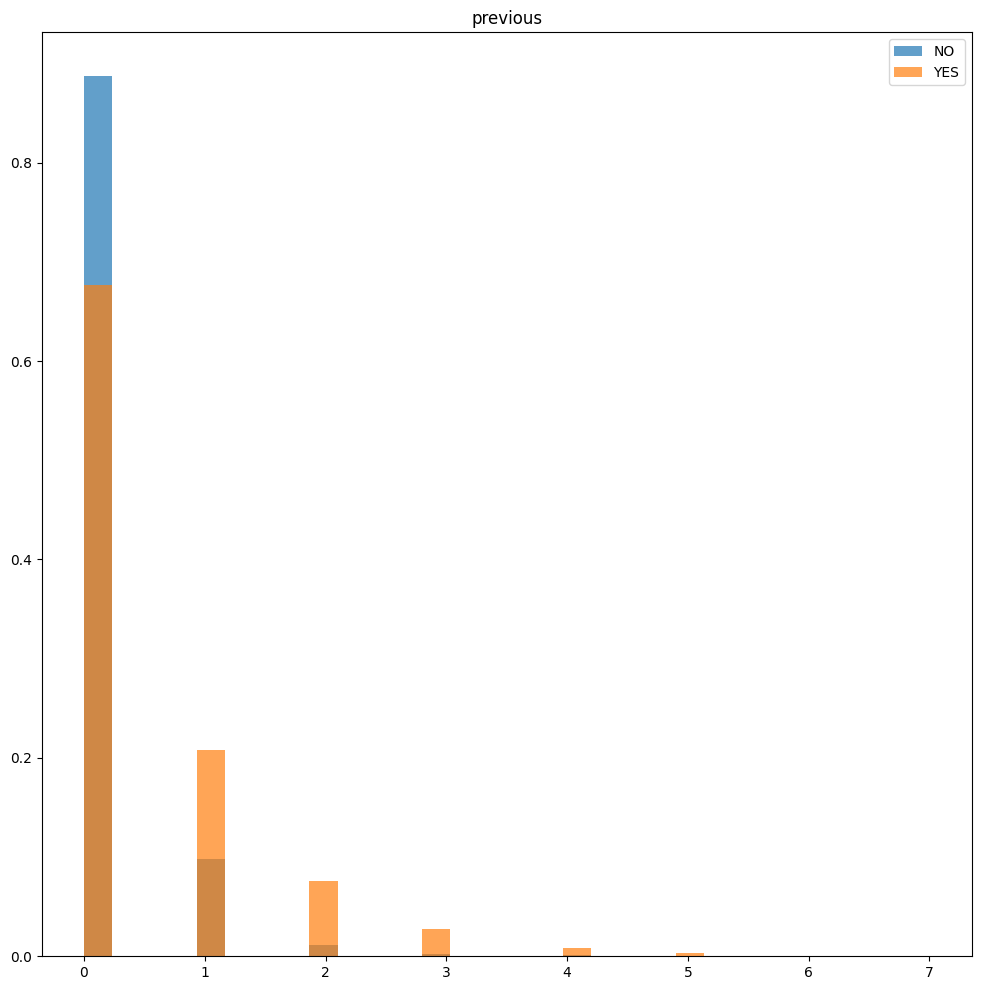

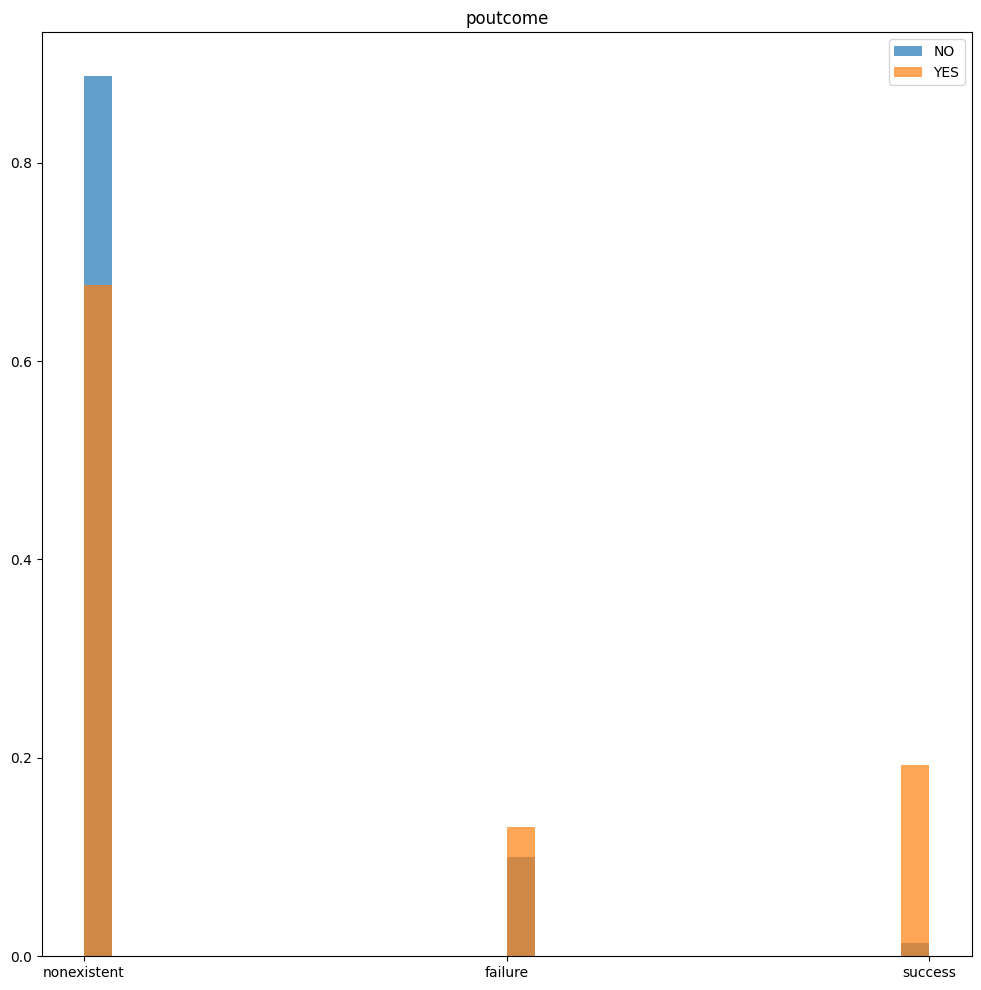

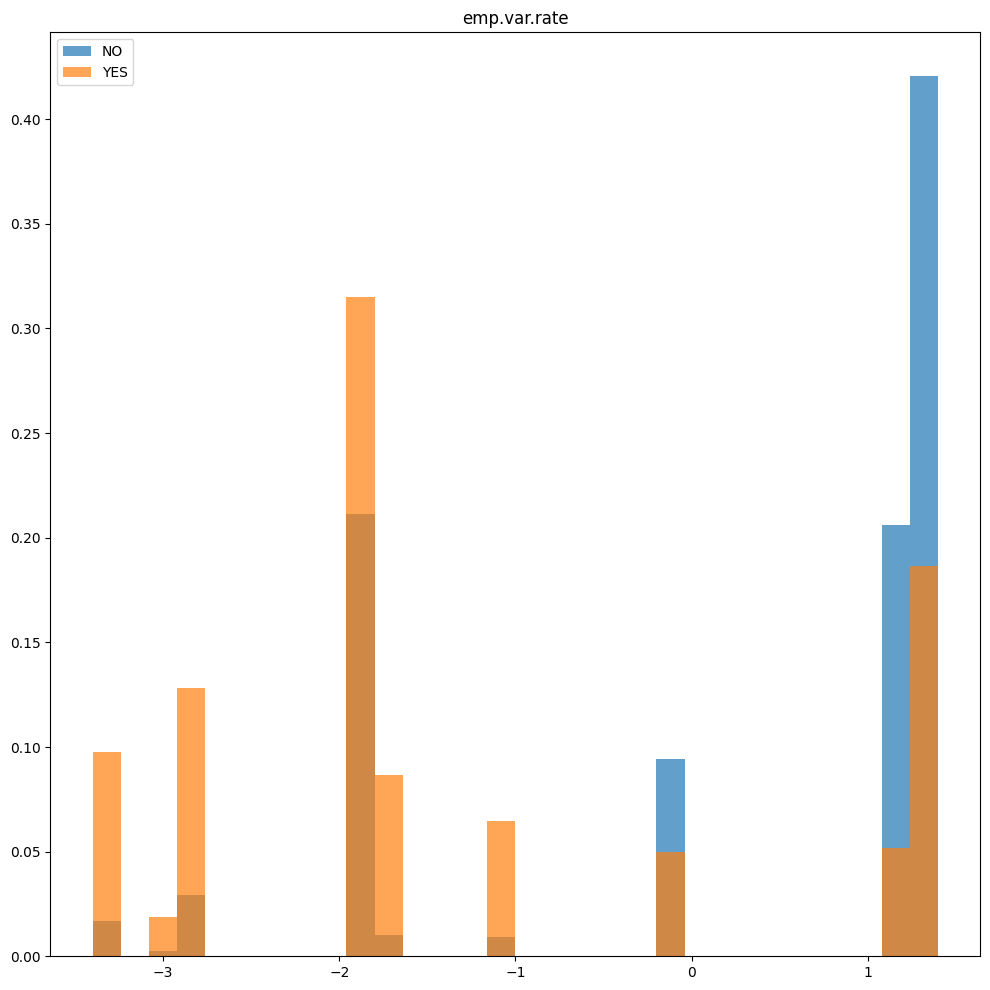

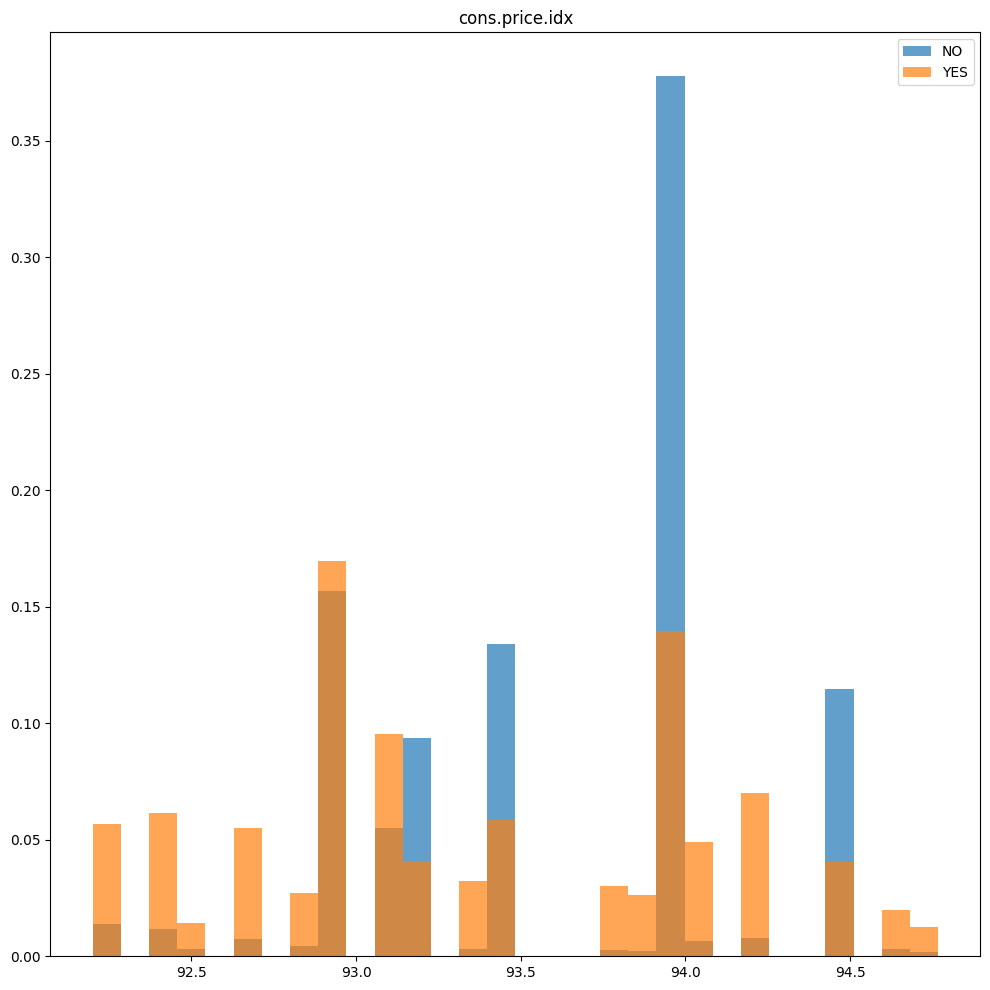

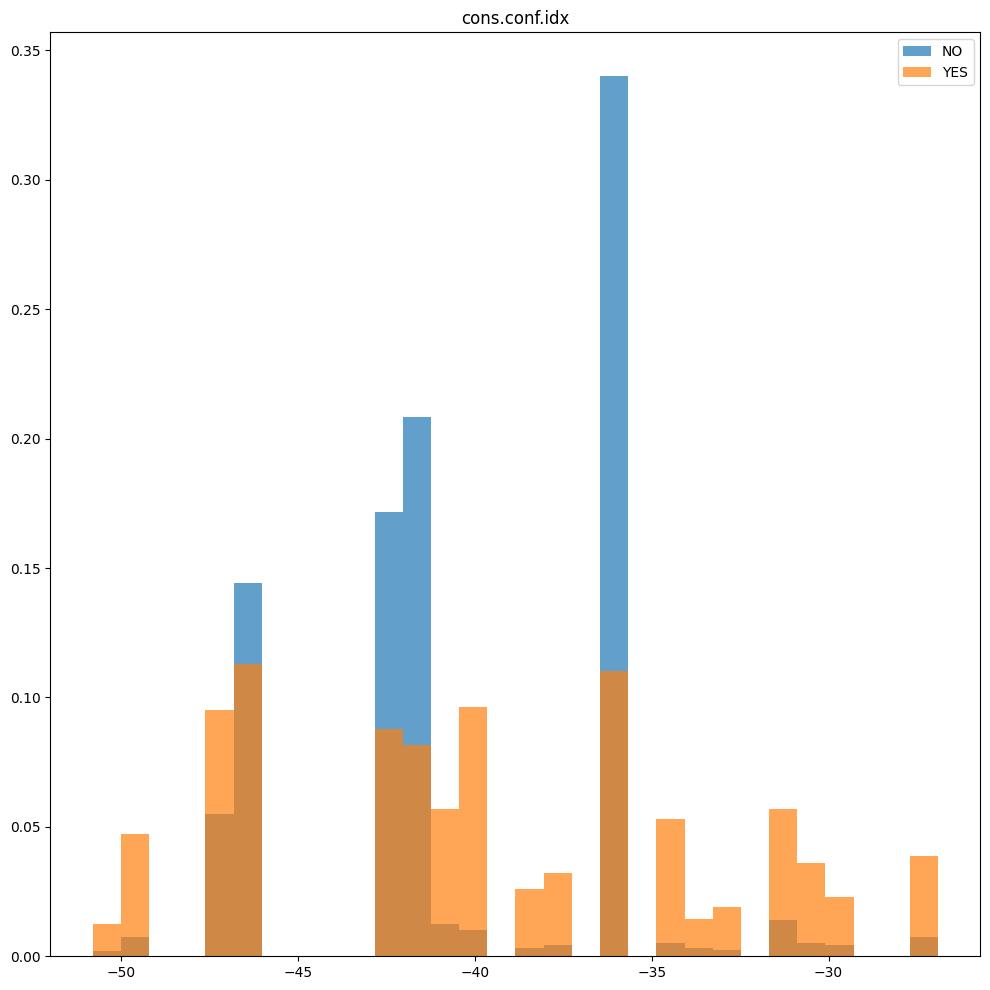

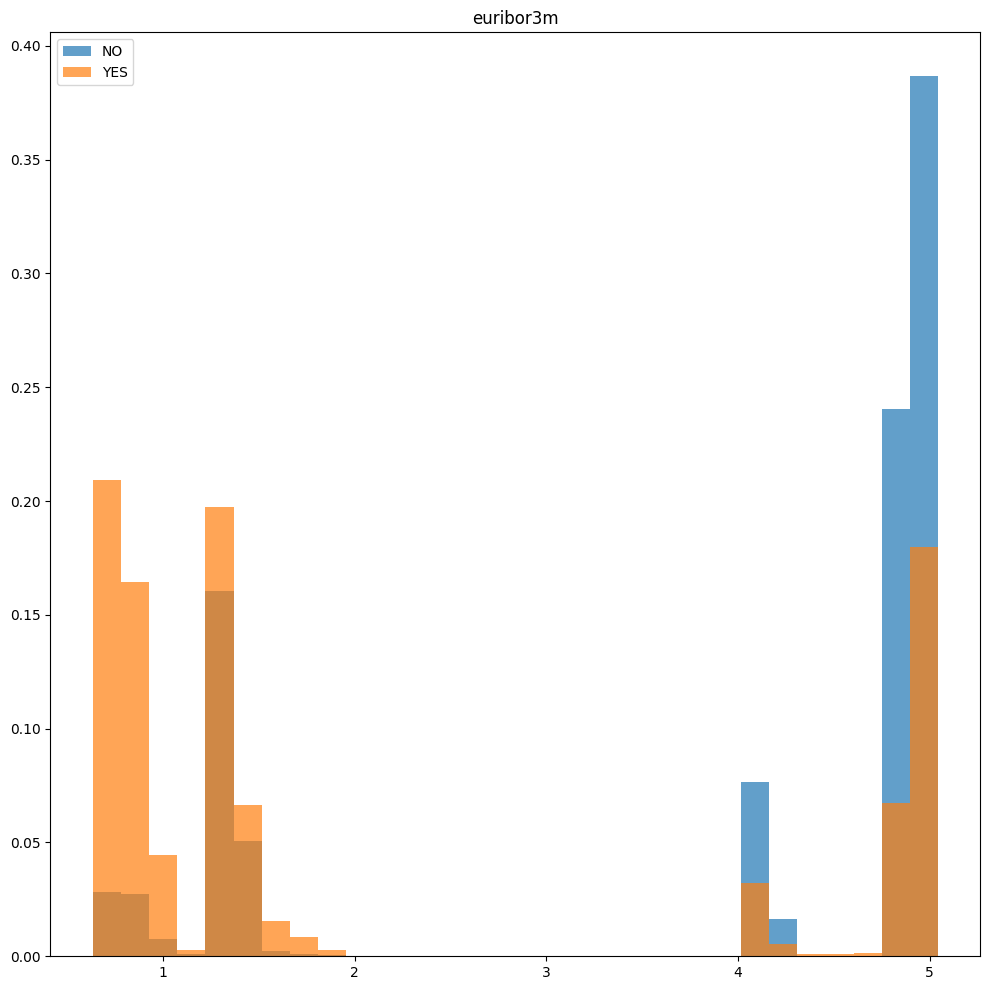

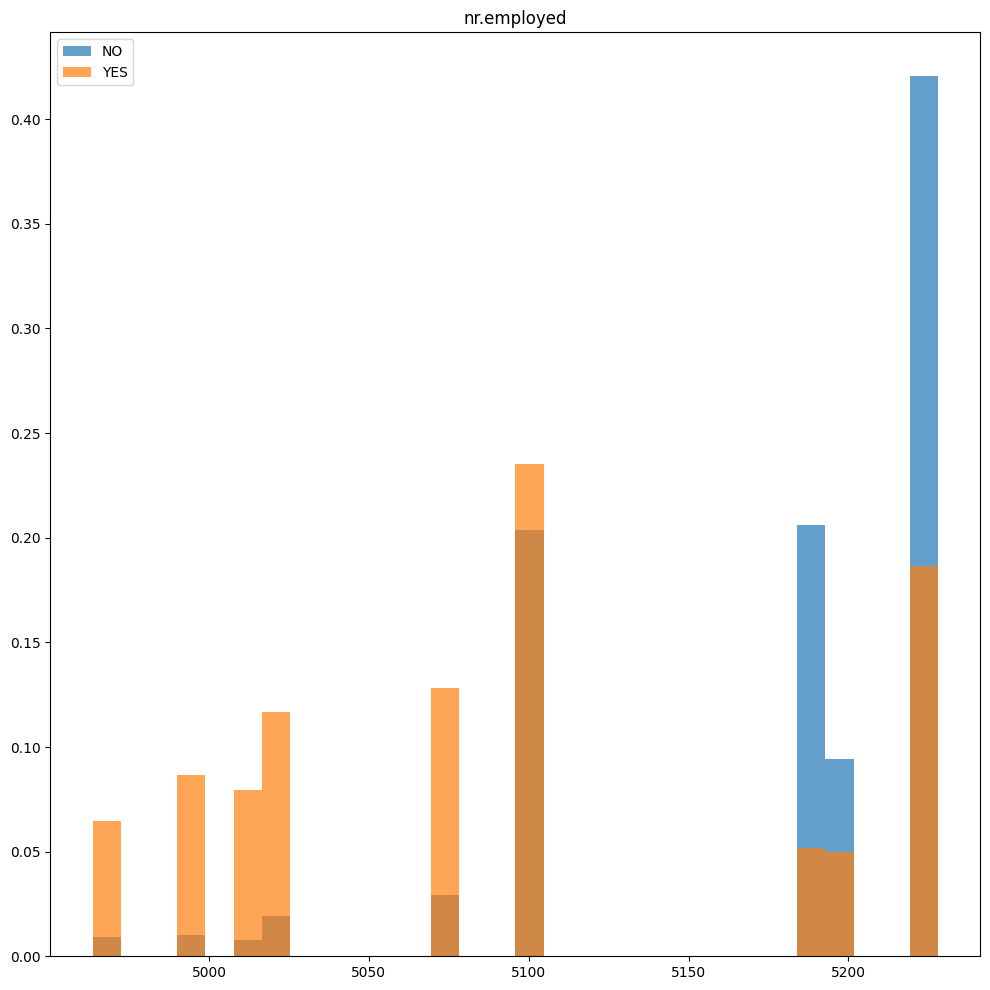

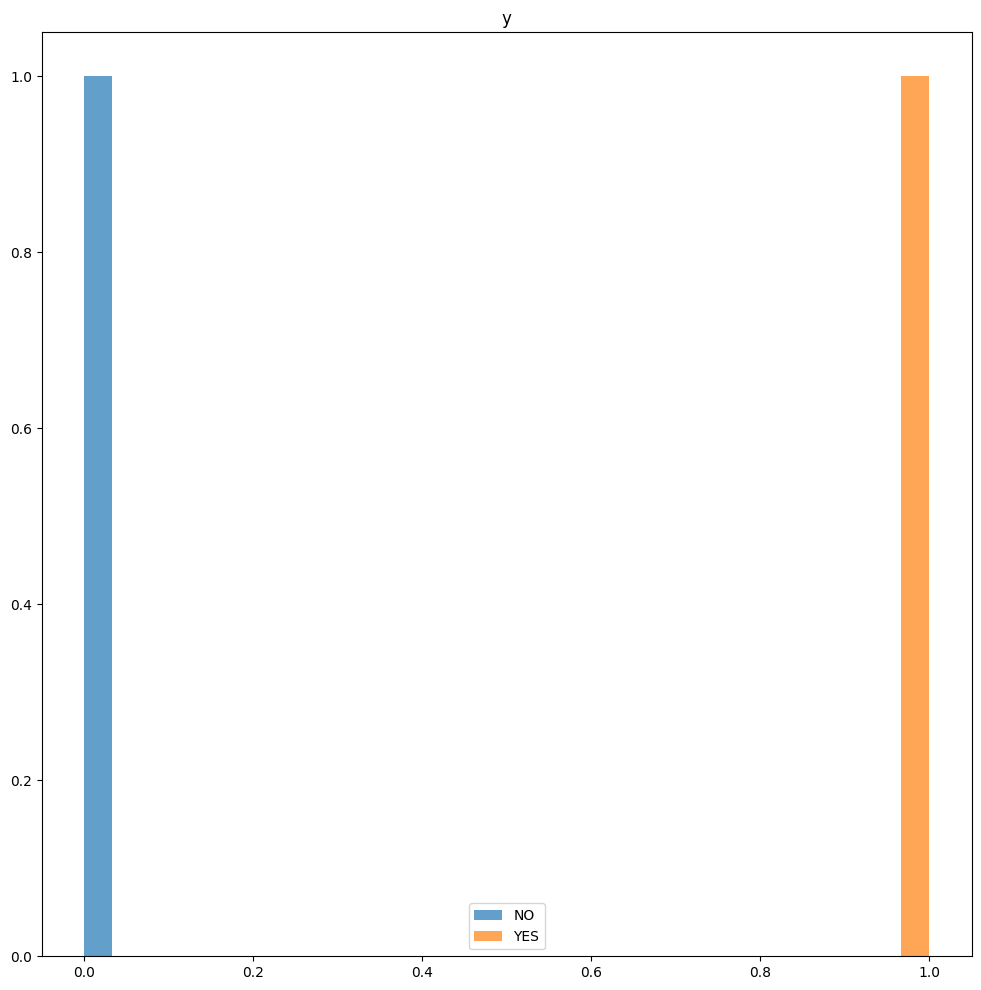

In [ ]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(12,12))
    cl0 = df.loc[df["y"]==0,col]
    cl1 = df.loc[df["y"]==1,col]
    if not any(pd.to_numeric(cl0, errors='coerce').isna()):
      bins = np.histogram(df.loc[:,col], bins=30)[1]
      ax.hist(cl0,bins=bins, alpha=0.7, label="NO", weights=(cl0==None)*0+1/sum(df["y"]==0))
      ax.hist(cl1,bins=bins, alpha=0.7, label="YES", weights=(cl1==None)*0+1/sum(df["y"]))
    else:
      ax.hist(cl0,bins=30, alpha=0.7, label="NO", weights=(cl0==None)*0+1/sum(df["y"]==0))
      ax.hist(cl1,bins=30, alpha=0.7, label="YES", weights=(cl1==None)*0+1/sum(df["y"]))
    ax.legend()
    ax.set_title(col)

(array([0.01034126, 0.00827301, 0.03826267, 0.3081696 , 0.06514995,
        0.02998966, 0.29886246, 0.04136505, 0.01240951, 0.        ,
        0.03619442, 0.03102378, 0.01551189, 0.02688728, 0.02895553,
        0.01137539, 0.01654602, 0.00620476, 0.00206825, 0.        ,
        0.0041365 , 0.00103413, 0.        , 0.00206825, 0.00206825,
        0.        , 0.        , 0.00103413, 0.00103413, 0.00103413]),
 array([ 0. ,  0.9,  1.8,  2.7,  3.6,  4.5,  5.4,  6.3,  7.2,  8.1,  9. ,
         9.9, 10.8, 11.7, 12.6, 13.5, 14.4, 15.3, 16.2, 17.1, 18. , 18.9,
        19.8, 20.7, 21.6, 22.5, 23.4, 24.3, 25.2, 26.1, 27. ]),
 <BarContainer object of 30 artists>)

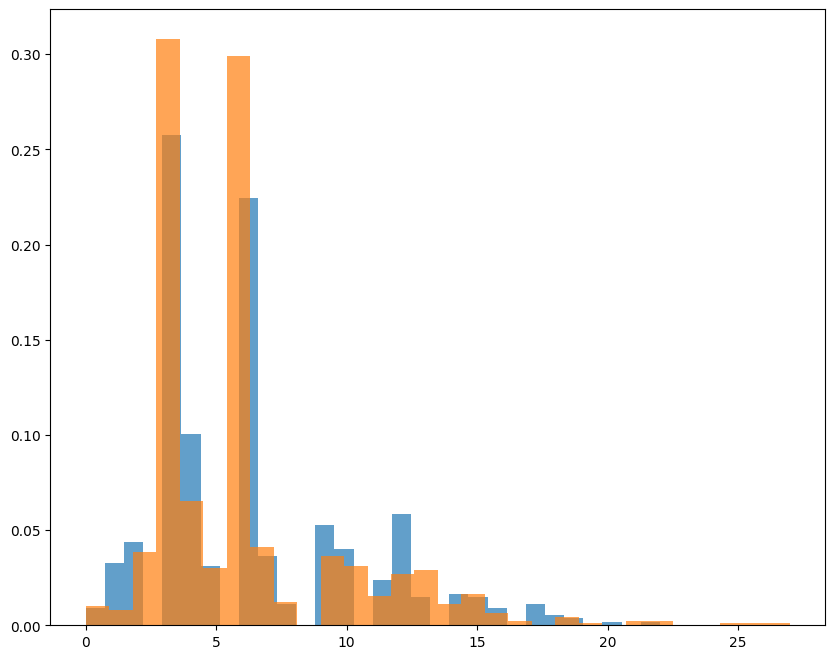

In [ ]:
plt.figure(figsize=(10,8))
cl0 = df.loc[(df["y"]==0)&(df['pdays']!=999),'pdays']
cl1 = df.loc[(df["y"]==1)&(df['pdays']!=999),'pdays']
plt.hist(cl0,bins=30, alpha=0.7, label="NO", weights=(cl0==None)*0+1/sum(df["y"][df['pdays']!=999]==0))
plt.hist(cl1,bins=30, alpha=0.7, label="YES", weights=(cl1==None)*0+1/sum(df["y"][df['pdays']!=999]))

In [15]:
corr = df.corr(method='spearman',numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.002123,0.005715,-0.001062,-0.012643,0.045003,0.044790,0.114536,0.054391,0.044789,-0.011861
duration,-0.002123,1.000000,-0.080953,-0.083072,0.042407,-0.069201,0.002854,-0.008678,-0.078346,-0.095225,0.348777
campaign,0.005715,-0.080953,1.000000,0.055514,-0.087420,0.156360,0.096494,-0.001554,0.140512,0.144264,-0.063668
pdays,-0.001062,-0.083072,0.055514,1.000000,-0.509583,0.227698,0.056763,-0.077265,0.278488,0.290673,-0.324942
previous,-0.012643,0.042407,-0.087420,-0.509583,1.000000,-0.435293,-0.282720,-0.115967,-0.454724,-0.438721,0.200914
emp.var.rate,0.045003,-0.069201,0.156360,0.227698,-0.435293,1.000000,0.664890,0.224693,0.939915,0.944702,-0.247480
cons.price.idx,0.044790,0.002854,0.096494,0.056763,-0.282720,0.664890,1.000000,0.245633,0.490970,0.464738,-0.122187
cons.conf.idx,0.114536,-0.008678,-0.001554,-0.077265,-0.115967,0.224693,0.245633,1.000000,0.236646,0.132707,0.041229
euribor3m,0.054391,-0.078346,0.140512,0.278488,-0.454724,0.939915,0.490970,0.236646,1.000000,0.928857,-0.266822
nr.employed,0.044789,-0.095225,0.144264,0.290673,-0.438721,0.944702,0.464738,0.132707,0.928857,1.000000,-0.283957


# Przygotowanie danych

Wnoski z histogramów

Istotne cechy:

numeryczne:
*   age ?
*   pdays
*   previous
*   emp.var.rate
*   cons.price.idx
*   euribor3m
*   nr.employed

Emp.var.rate, Euribor3m, Nr.employed - silny wspólny związek (patrz macierz korelacji wzajemnej)

kategoryczne:
*   job (blue-collar, services, entrepreneur, technician, housemaid, self-employed, management, unknown, un-employed, admin., student, retired)
*   martial (married, divorced, unknown, single) /divorced i unknown jako jedna kategoria?
*   education ()
*   default (yes, unknown, no)
*   housing ? - bardzo słabe
*   contact (telephone - 0, cellular - 1)
*   month (gorąca jedynka)
*   day_of_week ? - słabe
*   poutcome (nonexistent, failure, success)

Usunięcie zbędnych kolumn

In [88]:
df=df[['age','pdays','previous','emp.var.rate','cons.price.idx','euribor3m','nr.employed','job',"marital",'education','default','contact','month','poutcome','y']]

## Przetwarzanie cech - dane dyskretne

Zamina na wartości całkowite

In [89]:
df["job"] = df["job"].replace({"blue-collar":0, "services":1, "entrepreneur":2, "technician":3, "housemaid":4, "self-employed":5, "management":6, "unknown":7, "unemployed":8, "admin.":9, "student":10, "retired":11})
df["marital"] = df["marital"].replace({"married":-1, "divorced":0, "unknown":0, "single":1})
df["default"] = df["default"].replace({"yes":-1, "unknown":0, "no":1})
df["contact"] = df["contact"].replace({"telephone":0, "cellular":1})
df["poutcome"] = df["poutcome"].replace({"nonexistent":-1,"failure":0, "success":1})

/tmp/ipykernel_1295/1620118816.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["job"] = df["job"].replace({"blue-collar":0, "services":1, "entrepreneur":2, "technician":3, "housemaid":4, "self-employed":5, "management":6, "unknown":7, "unemployed":8, "admin.":9, "student":10, "retired":11})
/tmp/ipykernel_1295/1620118816.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["marital"] = df["marital"].replace({"married":-1, "divorced":0, "unknown":0, "single":1})
/tmp/ipykernel_1295/1620118816.py:3: FutureWarning: Downcasti

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# cat_cols = ["job","marital","education","default","contact","month","poutcome"]
# for col in cat_cols:
#   df[col] = LabelEncoder().fit_transform(df[col])
# df.head(n=10)

In [73]:
# df = pd.get_dummies(df, columns=["job"], drop_first=True)
# df.head(n=10)

In [90]:
df.head(n=10)

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,education,default,contact,month,poutcome,y
0,56,999,0,1.1,93.994,4.857,5191.0,4,-1,basic.4y,1,0,may,-1,0
1,57,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,0,0,may,-1,0
2,37,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,1,0,may,-1,0
3,40,999,0,1.1,93.994,4.857,5191.0,9,-1,basic.6y,1,0,may,-1,0
4,56,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,1,0,may,-1,0
5,45,999,0,1.1,93.994,4.857,5191.0,1,-1,basic.9y,0,0,may,-1,0
6,59,999,0,1.1,93.994,4.857,5191.0,9,-1,professional.course,1,0,may,-1,0
7,41,999,0,1.1,93.994,4.857,5191.0,0,-1,unknown,0,0,may,-1,0
8,24,999,0,1.1,93.994,4.857,5191.0,3,1,professional.course,1,0,may,-1,0
9,25,999,0,1.1,93.994,4.857,5191.0,1,1,high.school,1,0,may,-1,0


Metoda jeden kontra wszystkie

In [77]:
from sklearn.preprocessing import OneHotEncoder

In [78]:
for name in ["month","education"]:
  enc = OneHotEncoder(sparse_output=False)
  feat = enc.fit_transform(df[ [name] ])
  for group in enc.categories_:
    for i,cat in enumerate(group):
      df[cat]=feat[:,i]
  df.drop(columns=[name], inplace=True)

In [92]:
df = pd.get_dummies(df, columns=["month"], drop_first=True)

Sprawdzenie

In [93]:
pd.set_option('display.max_columns', None)
df.head(n=10)

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,education,default,contact,poutcome,y,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,56,999,0,1.1,93.994,4.857,5191.0,4,-1,basic.4y,1,0,-1,0,False,False,False,False,False,True,False,False,False
1,57,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,0,0,-1,0,False,False,False,False,False,True,False,False,False
2,37,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,1,0,-1,0,False,False,False,False,False,True,False,False,False
3,40,999,0,1.1,93.994,4.857,5191.0,9,-1,basic.6y,1,0,-1,0,False,False,False,False,False,True,False,False,False
4,56,999,0,1.1,93.994,4.857,5191.0,1,-1,high.school,1,0,-1,0,False,False,False,False,False,True,False,False,False
5,45,999,0,1.1,93.994,4.857,5191.0,1,-1,basic.9y,0,0,-1,0,False,False,False,False,False,True,False,False,False
6,59,999,0,1.1,93.994,4.857,5191.0,9,-1,professional.course,1,0,-1,0,False,False,False,False,False,True,False,False,False
7,41,999,0,1.1,93.994,4.857,5191.0,0,-1,unknown,0,0,-1,0,False,False,False,False,False,True,False,False,False
8,24,999,0,1.1,93.994,4.857,5191.0,3,1,professional.course,1,0,-1,0,False,False,False,False,False,True,False,False,False
9,25,999,0,1.1,93.994,4.857,5191.0,1,1,high.school,1,0,-1,0,False,False,False,False,False,True,False,False,False


Test korelacji

In [94]:
corr = df.corr(method='spearman',numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,default,contact,poutcome,y,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
age,1.000000,-0.001062,-0.012643,0.045003,0.044790,0.054391,0.044789,0.037861,-0.367234,-0.192404,-0.032814,-0.012211,-0.011861,0.064139,0.028306,-0.044901,-0.000136,-0.019862,-0.048276,0.037303,0.019356,0.012243
pdays,-0.001062,1.000000,-0.509583,0.227698,0.056763,0.278488,0.290673,-0.107293,-0.036904,-0.080063,-0.117994,-0.541775,-0.324942,-0.003263,-0.075744,0.050035,0.015640,-0.078154,0.070719,-0.017197,-0.128465,-0.154877
previous,-0.012643,-0.509583,1.000000,-0.435293,-0.282720,-0.454724,-0.438721,0.076282,0.047012,0.105290,0.242008,0.997328,0.200914,-0.073836,0.064029,-0.138762,-0.085740,0.066960,0.015318,0.102645,0.115359,0.130622
emp.var.rate,0.045003,0.227698,-0.435293,1.000000,0.664890,0.939915,0.944702,-0.084921,-0.069968,-0.177190,-0.231177,-0.436200,-0.247480,0.288644,-0.109571,0.435479,0.250585,-0.133086,-0.338158,-0.192477,-0.176148,-0.138519
cons.price.idx,0.044790,0.056763,-0.282720,0.664890,1.000000,0.490970,0.464738,-0.088725,-0.063886,-0.164980,-0.660197,-0.284661,-0.122187,-0.149648,-0.104505,0.142800,0.454576,-0.118390,-0.014159,-0.210529,-0.070529,-0.010290
euribor3m,0.054391,0.278488,-0.454724,0.939915,0.490970,1.000000,0.928857,-0.080187,-0.083372,-0.169507,-0.140998,-0.455137,-0.266822,0.397840,-0.106536,0.372582,0.134777,-0.132491,-0.326809,-0.192363,-0.176225,-0.180020
nr.employed,0.044789,0.290673,-0.438721,0.944702,0.464738,0.928857,1.000000,-0.091772,-0.072175,-0.157269,-0.109497,-0.438920,-0.283957,0.281845,-0.098094,0.417044,0.242985,-0.152136,-0.426872,0.000606,-0.195174,-0.199288
job,0.037861,-0.107293,0.076282,-0.084921,-0.088725,-0.080187,-0.091772,1.000000,0.137627,0.160407,0.108468,0.077449,0.120775,0.126740,0.048576,-0.031008,-0.033466,0.059721,-0.143849,0.041620,0.079950,0.078101
marital,-0.367234,-0.036904,0.047012,-0.069968,-0.063886,-0.083372,-0.072175,0.137627,1.000000,0.135240,0.069780,0.047091,0.049565,-0.034644,-0.002630,0.050067,-0.019775,0.045340,-0.018725,-0.011491,0.016369,0.008895
default,-0.192404,-0.080063,0.105290,-0.177190,-0.164980,-0.169507,-0.157269,0.160407,0.135240,1.000000,0.135411,0.105808,0.099350,0.008470,0.028821,-0.037635,-0.050146,0.051186,-0.067085,0.085804,0.060210,0.054719


In [95]:
corr.loc[["y"],:].style.background_gradient(cmap='coolwarm',axis=1)

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,default,contact,poutcome,y,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
y,-0.011861,-0.324942,0.200914,-0.247480,-0.122187,-0.266822,-0.283957,0.120775,0.049565,0.099350,0.144773,0.209219,1.000000,-0.008813,0.079303,-0.032230,-0.009182,0.144014,-0.108271,-0.011796,0.137366,0.126067


Dane znaczące:
- pdays
- nr.employed (silne powiązanie wzajemne)
- eurtibor3m (silne powiązanie wzajemne)
- emp.var.rate (silne powiązanie wzajemne)
- poutcome (silne powiązanie wzajemne)
- previous
- contact
- job
- default
- miesiące (mar, oct, sep, nov, may)

In [ ]:
# from sklearn.feature_selection import RFE
# from sklearn.svm import SVR

# estimator = SVR(kernel="linear")
# selector = RFE(estimator, n_features_to_select=5, step=1)
# selector = selector.fit(df.drop(columns=["y"]), df["y"])
# selector.support_
# selector.ranking_

## Podział danych

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.loc[df['y']==0,df.columns!='y'], df.loc[df['y']==0,['y']],
                                                    test_size=0.3, random_state=42)

X_train2, X_test2, y_train2, y_test2 = train_test_split(df.loc[df['y']==1,df.columns!='y'], df.loc[df['y']==1,['y']],
                                                    test_size=0.3, random_state=42)
X_train = pd.concat([X_train,X_train2])
y_train = pd.concat([y_train,y_train2])
X_test = pd.concat([X_test,X_test2])
y_test = pd.concat([y_test,y_test2])

## Przetwarzanie danych ciągłych / normalizacja



In [97]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[['age','pdays','previous','emp.var.rate','cons.price.idx','euribor3m','nr.employed']] = scaler.fit_transform(X_train[['age','pdays','previous','emp.var.rate','cons.price.idx','euribor3m','nr.employed']])

In [98]:
for i in X_train.columns: print(i)

age
pdays
previous
emp.var.rate
cons.price.idx
euribor3m
nr.employed
job
marital
education
default
contact
poutcome
month_aug
month_dec
month_jul
month_jun
month_mar
month_may
month_nov
month_oct
month_sep


In [99]:
X_train.head(5)

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,education,default,contact,poutcome,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
13094,-0.767095,0.196418,-0.349512,0.840583,0.592238,0.774483,0.845358,0,1,basic.4y,0,1,-1,False,False,True,False,False,False,False,False,False
11404,-0.100476,0.196418,-0.349512,0.840583,1.534543,0.772755,0.845358,1,0,basic.6y,1,0,-1,False,False,False,True,False,False,False,False,False
20745,1.613684,0.196418,-0.349512,0.840583,-0.224312,0.776212,0.845358,0,-1,basic.9y,0,1,-1,True,False,False,False,False,False,False,False,False
3117,-0.862326,0.196418,-0.349512,0.649835,0.723161,0.715704,0.332550,1,-1,high.school,1,0,-1,False,False,False,False,False,True,False,False,False
17344,0.851835,0.196418,-0.349512,0.840583,0.592238,0.774483,0.845358,7,0,unknown,0,1,-1,False,False,True,False,False,False,False,False,False


In [100]:
X_test[['age','pdays','previous','emp.var.rate','cons.price.idx','euribor3m','nr.employed']] = scaler.transform(X_test[['age','pdays','previous','emp.var.rate','cons.price.idx','euribor3m','nr.employed']])

In [101]:
X_test.head(5)

,age,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job,marital,education,default,contact,poutcome,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
4155,-1.528944,0.196418,-0.349512,0.649835,0.723161,0.714551,0.332550,0,-1,basic.9y,1,0,-1,False,False,False,False,False,True,False,False,False
6627,-0.290939,0.196418,-0.349512,0.649835,0.723161,0.713975,0.332550,6,-1,university.degree,1,0,-1,False,False,False,False,False,True,False,False,False
30628,0.375679,-5.059354,1.669072,-1.194062,-1.173509,-1.304698,-0.937719,5,1,professional.course,1,1,1,False,False,False,False,False,True,False,False,False
33335,-0.671863,0.196418,-0.349512,-1.194062,-1.173509,-1.341003,-0.937719,0,1,basic.4y,1,1,-1,False,False,False,False,False,True,False,False,False
34134,-0.005245,0.196418,-0.349512,-1.194062,-1.173509,-1.346765,-0.937719,0,-1,basic.9y,0,1,-1,False,False,False,False,False,True,False,False,False


Wybór kolumn

In [102]:
X_train_cp = X_train.copy()
X_test_cp = X_test.copy()

In [103]:
tablica_wynikow = pd.DataFrame(columns=['LR', 'KNN', 'DT', 'NB', 'SVM', 'MLP'])

In [104]:
cols = ['pdays', 'nr.employed', 'euribor3m', 'emp.var.rate', 'poutcome', 'previous', 'contact', 'job', 'default']

X_train = X_train_cp[cols]
X_test = X_test_cp[cols]

In [ ]:
# cols = X_train.columns

# Trenowanie modeli

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, cohen_kappa_score, brier_score_loss, balanced_accuracy_score,class_likelihood_ratios

## Regresja Logistyczna (LR)

In [106]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, np.ravel(y_train))

LogisticRegression()

In [107]:
y_pred_lr = clf.predict(X_test)

In [108]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_lr))
print('        precision_score :',precision_score(y_test, y_pred_lr))
print('           recall_score :',recall_score(y_test, y_pred_lr))
print('               f1_score :',f1_score(y_test, y_pred_lr))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_lr))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_lr))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_lr))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_lr))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_lr))

         accuracy_score : 0.8993283159342883
        precision_score : 0.6705069124423964
           recall_score : 0.20905172413793102
               f1_score : 0.3187294633077766
          roc_auc_score : 0.5980051142349482
balanced_accuracy_score : 0.5980051142349482
      cohen_kappa_score : 0.2801846220757003
       brier_score_loss : 0.10067168406571174
class_likelihood_ratios : (np.float64(16.02973535085604), np.float64(0.80139972692918))


In [109]:
pd.DataFrame(confusion_matrix(y_test, y_pred_lr),
                      index=['Actual Negative (0)', 'Actual Positive (1)'],
                      columns=['Predicted Negative (0)', 'Predicted Positive (1)'])

,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),10822,143
Actual Positive (1),1101,291


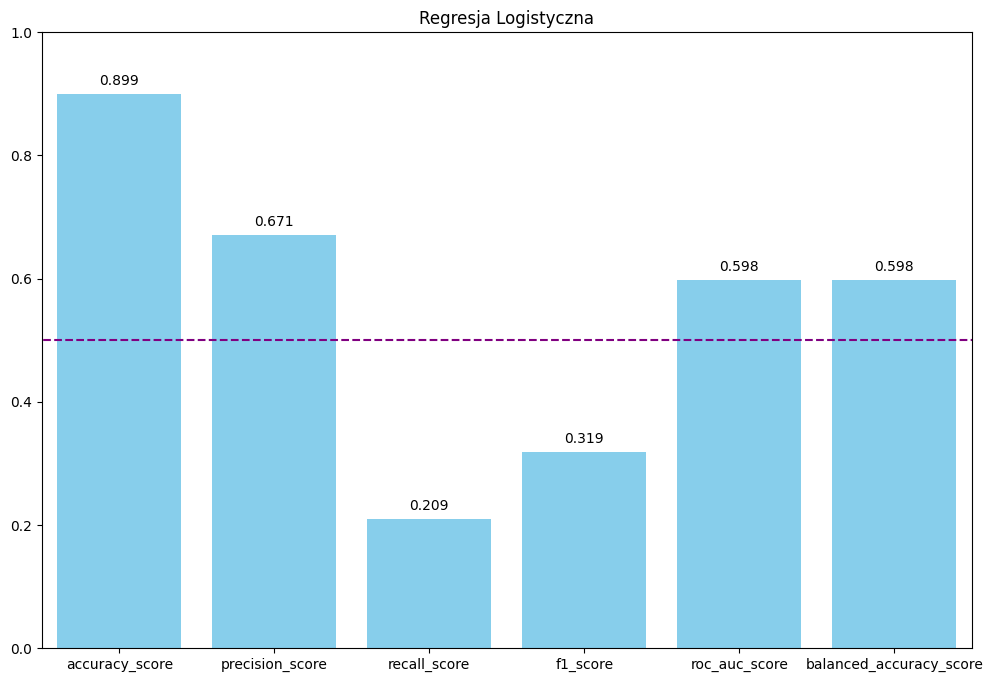

In [110]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_pred_lr),
    balanced_accuracy_score(y_test, y_pred_lr)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("Regresja Logistyczna")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## K Najbliższych Sąsiadów (KNN)

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors':[2,5,8]}
knn = KNeighborsClassifier()
clf = GridSearchCV(knn, parameters)
clf.fit(X_train, np.ravel(y_train))

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 5, 8]})

In [112]:
y_pred_knn = clf.predict(X_test)

In [113]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_knn))
print('        precision_score :',precision_score(y_test, y_pred_knn))
print('           recall_score :',recall_score(y_test, y_pred_knn))
print('               f1_score :',f1_score(y_test, y_pred_knn))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_knn))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_knn))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_knn))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_knn))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_knn))

         accuracy_score : 0.8960103585012543
        precision_score : 0.5824345146379045
           recall_score : 0.27155172413793105
               f1_score : 0.370406663400294
          roc_auc_score : 0.6234183609289746
balanced_accuracy_score : 0.6234183609289746
      cohen_kappa_score : 0.32182171376470325
       brier_score_loss : 0.10398964149874565
class_likelihood_ratios : (np.float64(10.987323450820716), np.float64(0.7469081115417604))


In [114]:
print(confusion_matrix(y_test, y_pred_knn))

[[10694   271]
 [ 1014   378]]


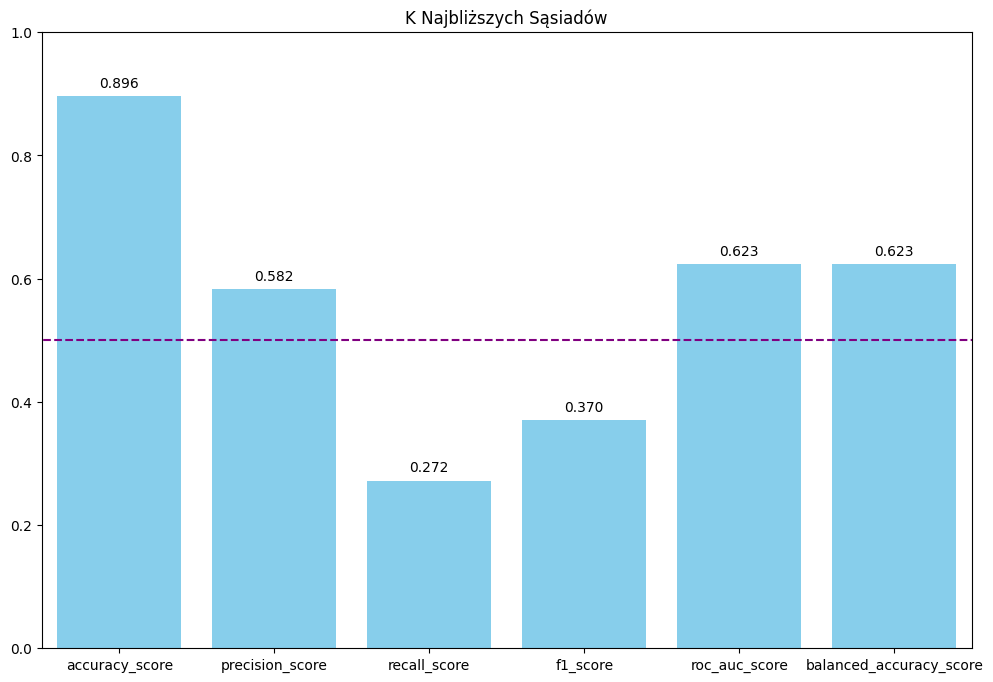

In [115]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    roc_auc_score(y_test, y_pred_knn),
    balanced_accuracy_score(y_test, y_pred_knn)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("K Najbliższych Sąsiadów")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Drzewo Decyzyjne (DT)

In [116]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, np.ravel(y_train))

DecisionTreeClassifier(max_depth=5)

In [117]:
y_pred_dt = clf.predict(X_test)

In [118]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_dt))
print('        precision_score :',precision_score(y_test, y_pred_dt))
print('           recall_score :',recall_score(y_test, y_pred_dt))
print('               f1_score :',f1_score(y_test, y_pred_dt))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_dt))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_dt))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_dt))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_dt))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_dt))

         accuracy_score : 0.9002994254268836
        precision_score : 0.6619433198380567
           recall_score : 0.2349137931034483
               f1_score : 0.34676564156945916
          roc_auc_score : 0.6098417574728368
balanced_accuracy_score : 0.6098417574728368
      cohen_kappa_score : 0.3057993691383395
       brier_score_loss : 0.09970057457311646
class_likelihood_ratios : (np.float64(15.424130187900062), np.float64(0.7769188978163262))


In [119]:
print(confusion_matrix(y_test, y_pred_dt))

[[10798   167]
 [ 1065   327]]


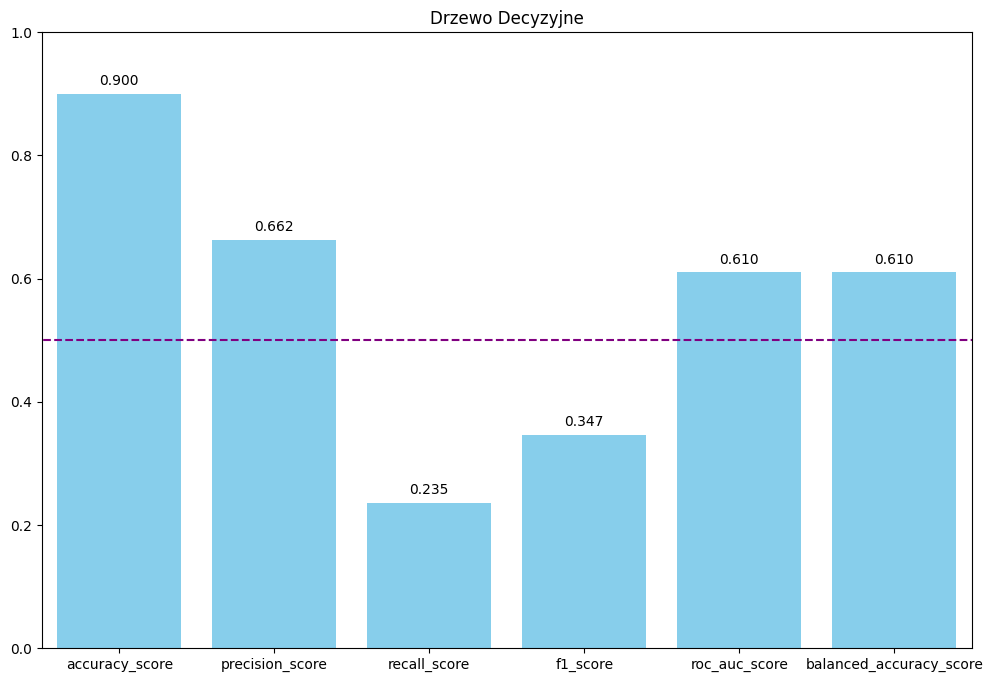

In [120]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_pred_dt),
    balanced_accuracy_score(y_test, y_pred_dt)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("Drzewo Decyzyjne")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Naive Bayes (NB)

In [121]:
from sklearn.naive_bayes import BernoulliNB
clf = BernoulliNB()
clf.fit(X_train, np.ravel(y_train))

BernoulliNB()

In [122]:
y_pred_nb = clf.predict(X_test)

In [123]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_nb))
print('        precision_score :',precision_score(y_test, y_pred_nb))
print('           recall_score :',recall_score(y_test, y_pred_nb))
print('               f1_score :',f1_score(y_test, y_pred_nb))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_nb))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_nb))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_nb))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_nb))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_nb))

         accuracy_score : 0.7730031561058509
        precision_score : 0.27435324177579046
           recall_score : 0.6170977011494253
               f1_score : 0.3798363917753703
          roc_auc_score : 0.7049464793936822
balanced_accuracy_score : 0.7049464793936822
      cohen_kappa_score : 0.26524399337118
       brier_score_loss : 0.22699684389414906
class_likelihood_ratios : (np.float64(2.978202593795532), np.float64(0.48297753444110797))


In [124]:
print(confusion_matrix(y_test, y_pred_nb))

[[8693 2272]
 [ 533  859]]


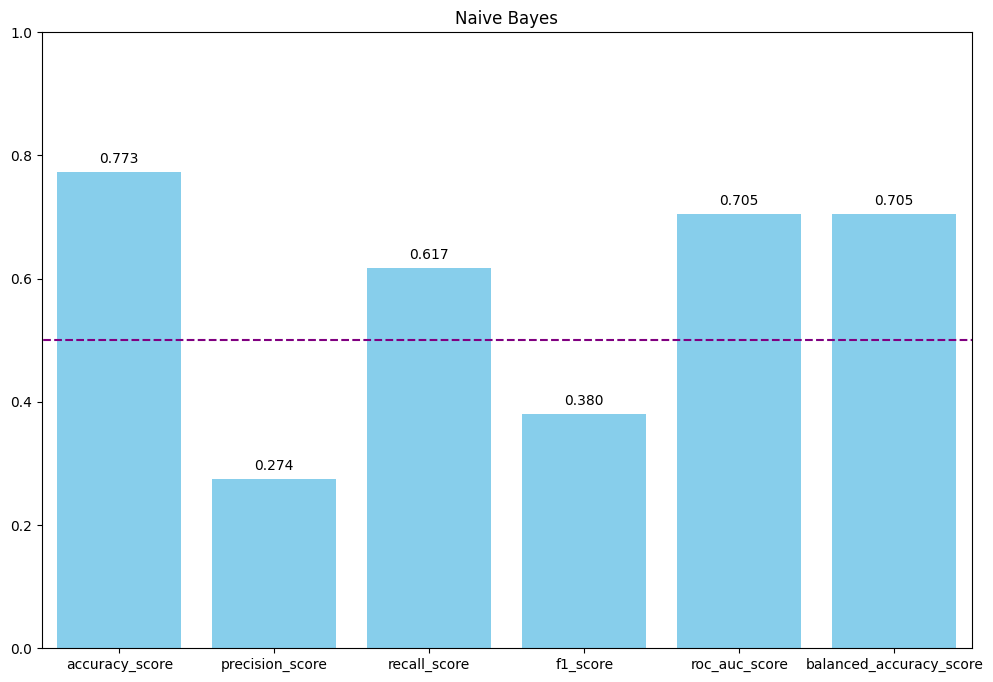

In [125]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb),
    roc_auc_score(y_test, y_pred_nb),
    balanced_accuracy_score(y_test, y_pred_nb)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("Naive Bayes")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Maszyna Wektorów Nośnych (SVM)

In [126]:
from sklearn.svm import SVC
clf = SVC(kernel='rbf')
clf.fit(X_train, np.ravel(y_train))

SVC()

In [127]:
y_pred_svm = clf.predict(X_test)

In [128]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_svm))
print('        precision_score :',precision_score(y_test, y_pred_svm))
print('           recall_score :',recall_score(y_test, y_pred_svm))
print('               f1_score :',f1_score(y_test, y_pred_svm))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_svm))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_svm))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_svm))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_svm))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_svm))

         accuracy_score : 0.8983572064416929
        precision_score : 0.6683168316831684
           recall_score : 0.1939655172413793
               f1_score : 0.30066815144766146
          roc_auc_score : 0.5908724075034986
balanced_accuracy_score : 0.5908724075034986
      cohen_kappa_score : 0.2633344022309011
       brier_score_loss : 0.10164279355830703
class_likelihood_ratios : (np.float64(15.871879825012867), np.float64(0.8160066571367626))


In [129]:
print(confusion_matrix(y_test, y_pred_svm))

[[10831   134]
 [ 1122   270]]


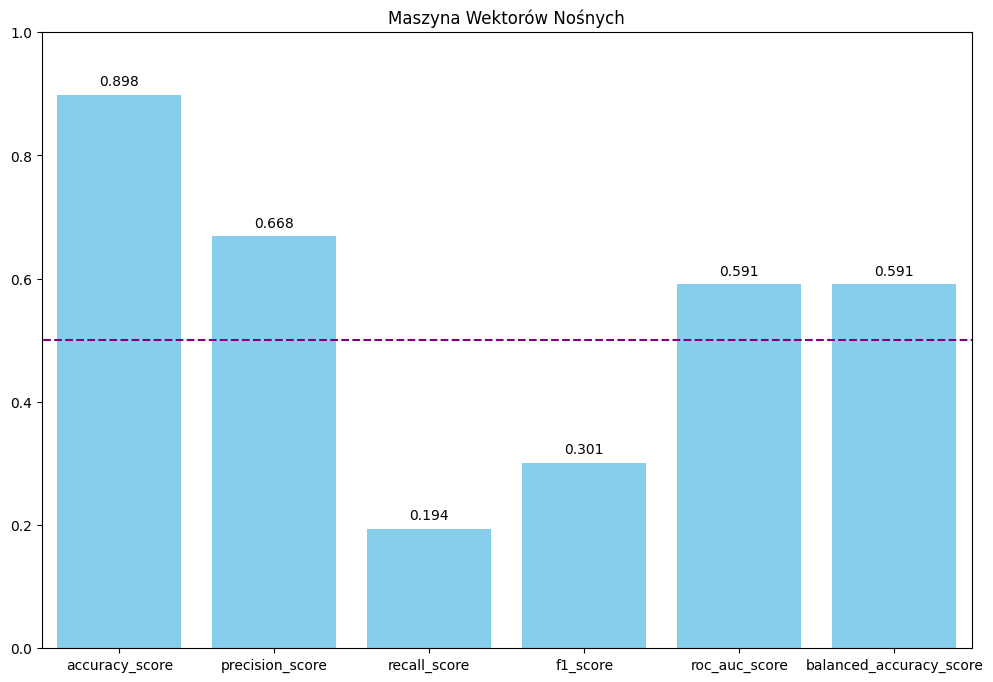

In [130]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    roc_auc_score(y_test, y_pred_svm),
    balanced_accuracy_score(y_test, y_pred_svm)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("Maszyna Wektorów Nośnych")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Perceptron Wielowarstwowy (MLP)

In [131]:
# from sklearn.neural_network import MLPClassifier
# from sklearn.model_selection import GridSearchCV
# parameters = {'hidden_layer_sizes':[(24,24,24),(36,36,36)], 'max_iter':[1000], 'alpha':[0.0001,0.001,0.00001]}
# mlp = MLPClassifier()
# clf = GridSearchCV(mlp, parameters)
# clf.fit(X_train, np.ravel(y_train))

In [132]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(24,24,24), max_iter=1000, alpha=0.0001)
clf.fit(X_train, np.ravel(y_train))

MLPClassifier(hidden_layer_sizes=(24, 24, 24), max_iter=1000)

In [133]:
y_pred_mlp = clf.predict(X_test)

In [134]:
print('         accuracy_score :',accuracy_score(y_test, y_pred_mlp))
print('        precision_score :',precision_score(y_test, y_pred_mlp))
print('           recall_score :',recall_score(y_test, y_pred_mlp))
print('               f1_score :',f1_score(y_test, y_pred_mlp))
print('          roc_auc_score :',roc_auc_score(y_test, y_pred_mlp))
print('balanced_accuracy_score :',balanced_accuracy_score(y_test, y_pred_mlp))
print('      cohen_kappa_score :',cohen_kappa_score(y_test, y_pred_mlp))
print('       brier_score_loss :',brier_score_loss(y_test, y_pred_mlp))
print('class_likelihood_ratios :',class_likelihood_ratios(y_test, y_pred_mlp))

         accuracy_score : 0.9020797928299749
        precision_score : 0.6763565891472868
           recall_score : 0.2507183908045977
               f1_score : 0.3658280922431866
          roc_auc_score : 0.6177440563234113
balanced_accuracy_score : 0.6177440563234115
      cohen_kappa_score : 0.32468126897305283
       brier_score_loss : 0.09792020717002509
class_likelihood_ratios : (np.float64(16.461839252529423), np.float64(0.7608698689412471))


In [135]:
print(confusion_matrix(y_test, y_pred_mlp))

[[10798   167]
 [ 1043   349]]


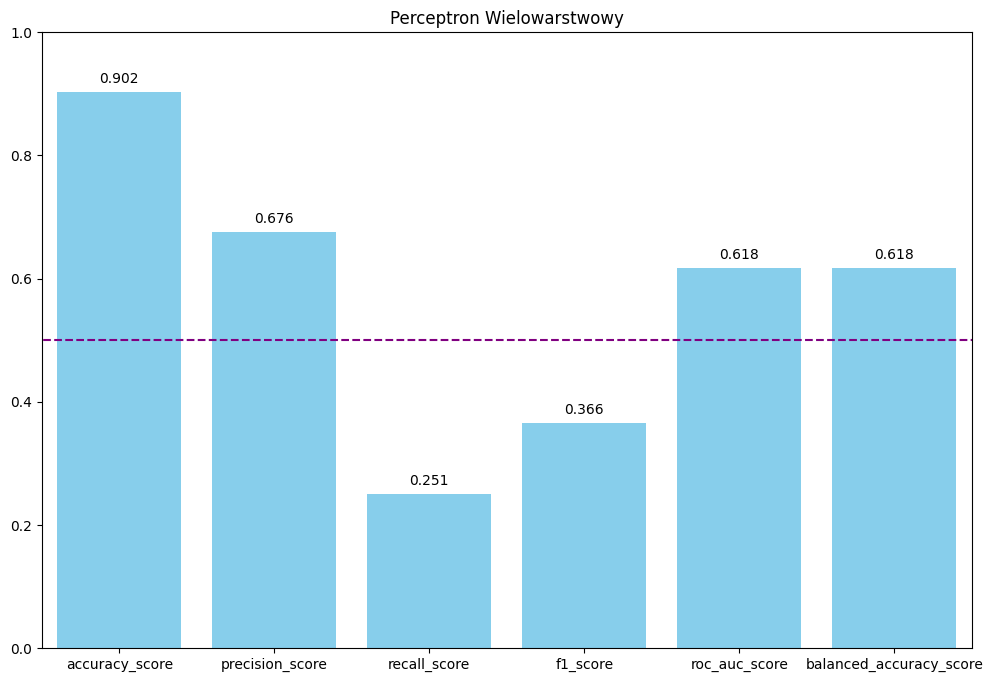

In [136]:
plt.figure(figsize=(12,8))
metrics_names = ["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score", "balanced_accuracy_score"]
metrics_values = [
    accuracy_score(y_test, y_pred_mlp),
    precision_score(y_test, y_pred_mlp),
    recall_score(y_test, y_pred_mlp),
    f1_score(y_test, y_pred_mlp),
    roc_auc_score(y_test, y_pred_mlp),
    balanced_accuracy_score(y_test, y_pred_mlp)]

plt.bar(metrics_names,metrics_values, color='skyblue')
plt.xticks(rotation=0)
plt.xlim(-0.5,5.5)
plt.ylim(0,1)
plt.hlines(y=0.5, xmin=-1, xmax=5.5, linestyles='dashed', color="purple")
plt.title("Perceptron Wielowarstwowy")

for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='black')

plt.show()

# Wyniki analizy pod kątem doboru danych wejściowych

In [137]:
def bas(y_test, y_pred):
  return balanced_accuracy_score(y_test, y_pred)

wyniki = [[bas(y_test, y_pred_lr)],[bas(y_test, y_pred_knn)],[bas(y_test, y_pred_dt)],[bas(y_test, y_pred_nb)],[bas(y_test, y_pred_svm)], [bas(y_test, y_pred_mlp)]]

In [138]:
tablica_wynikow = pd.concat([tablica_wynikow, pd.DataFrame(wyniki, index=tablica_wynikow.columns, columns=[str(cols)]).T])

/tmp/ipykernel_1295/1772930969.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tablica_wynikow = pd.concat([tablica_wynikow, pd.DataFrame(wyniki, index=tablica_wynikow.columns, columns=[str(cols)]).T])


Tablica balanced accuracy

In [139]:
tablica_wynikow

,LR,KNN,DT,NB,SVM,MLP
"['pdays', 'nr.employed', 'euribor3m', 'emp.var.rate', 'poutcome', 'previous', 'contact', 'job', 'default']",0.598005,0.623418,0.609842,0.704946,0.590872,0.617744


In [140]:
# tablica_wynikow.to_excel("wyniki.xlsx")

Wybrano opcję pierwszą, czyli ['pdays', 'nr.employed', 'euribor3m', 'emp.var.rate', 'poutcome', 'previous', 'contact', 'job', 'default']

# Wnioski

Powyższa analiza i uzyskane modele wskazują, że:


*   Różne metryki są w stanie pokazać różne cechy uzyskanego modelu.
*   Warto sprawdzić wiele metryk, aby lepiej stwierdzić mocne i słabe strony modelu.
*   Duże niezrównoważenie danych sprzyja zwrostowi jednych metryk kosztem drugich. (precision i recall)
*   Bardziej rozbudowane modele mają tendencje do uzyskania większej dokładności (całego modelui) kosztem dokładności rozpoznawania poszczególnych klas


